# Project 2
## Lawrence Liu Jackie McGinley

# Background
#### A large company named Canterra, employs, at any given point of time, around 4000 employees. However, every year, around 15% of its employees leave the company and need to be replaced with the talent pool available in the job market. The management believes that this level of attrition (employees leaving, either on their own or because they got fired) is bad for the company, because of the following reasons:
- The former employees’ projects get delayed, which makes it difficult to meet timelines, resulting in a reputation loss among consumers and partners
- A sizable department has to be maintained, for the purposes of recruiting new talent
- More often than not, the new employees have to be trained for the job and/or given time to acclimatize themselves to the company
#### The management hypothesizes that higher job satisfaction and a higher number of total working years will reduce employee attrition. Additionally, the marketing management was interested to know if demographic variables such as gender, education and age affect employee attrition. Hence, the management has contracted you as a consultant to understand whether these two factors they should focus on, in order to curb attrition. In other words, they want to know if changes in their internal and external recruitment strategies would help retain employees.



---

#### import the important libraries needed

In [48]:
### Step 0: Setup ----
# Load any libraries used for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
# for stepwise selection later
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression


---

#### first check to see if the data set has nulls

In [49]:
# -------------------------------------------------------------------
# Step 1: Pre-processing
# -------------------------------------------------------------------

print("Do we have missing values? Look at 'Non-Null Count'")
df = pd.read_excel('Employee_Data_Project.xlsx')
df.shape
print(df.info())


Do we have missing values? Look at 'Non-Null Count'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   DistanceFromHome         4410 non-null   int64  
 4   Education                4410 non-null   int64  
 5   EmployeeID               4410 non-null   int64  
 6   Gender                   4410 non-null   object 
 7   JobLevel                 4410 non-null   int64  
 8   MaritalStatus            4410 non-null   object 
 9   Income                   4410 non-null   int64  
 10  NumCompaniesWorked       4391 non-null   float64
 11  StandardHours            4410 non-null   int64  
 12  TotalWorkingYears        4401 non-null   float64
 13  TrainingTimesLastYear    4

---

#### visualize some of these rows

#### There are missing values in the NumCompaniesWorked , TotalWorkingYears , EnvironmentSatisfaction , JobSatisfaction Columns

In [50]:
# -------------------------------------------------------------------
# Step 1: Pre-processing (check rows with nulls and visualize those rows)
# -------------------------------------------------------------------
# first step is to get the index of where the nulls are and take a look at only those rows
null_rows = df[df.isnull().any(axis=1)].index
# use the index from null rows to view those rows
df.loc[null_rows]
## confirmed that there are truly NaNs (73 total rows have NaNs)

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EmployeeID,Gender,JobLevel,MaritalStatus,Income,NumCompaniesWorked,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction
11,36,No,Travel_Rarely,28,1,12,Male,1,Married,33770,0.0,8,16.0,2,15,11,NaN,4.0
23,42,No,Travel_Rarely,4,4,24,Male,1,Married,89260,1.0,8,NaN,4,20,6,2.0,3.0
40,36,No,Travel_Frequently,8,3,41,Female,3,Married,69620,4.0,8,4.0,2,1,0,3.0,NaN
111,31,No,Travel_Rarely,1,3,112,Male,4,Single,28670,0.0,8,3.0,5,2,2,NaN,2.0
115,27,No,Travel_Rarely,2,3,116,Male,1,Divorced,23670,NaN,8,5.0,2,5,4,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4226,36,No,Travel_Rarely,2,3,4227,Male,2,Married,43200,NaN,8,5.0,2,1,0,2.0,4.0
4332,31,No,Travel_Rarely,2,5,4333,Male,2,Married,27280,8.0,8,7.0,3,4,2,NaN,4.0
4345,43,No,Non-Travel,6,2,4346,Male,1,Divorced,20280,4.0,8,7.0,2,5,2,4.0,NaN
4395,40,No,Travel_Rarely,2,3,4396,Male,1,Divorced,27180,NaN,8,9.0,4,9,7,1.0,4.0


- 1.65% of the data is missing, to will do train test split then impute the missing values. 

---

# project code questions

---

#### Q1: Logistic Regression Rationale

##### Explain why logistic regression is an appropriate modeling technique for predicting employee attrition in this dataset compared to classical regression methods. 
- Employee Attrition is a binary variable coded as Yes/No. Will need the sigmoid function bounded by 1 and 0 to accurately predict. If we were to use Linear regression predictions would be continous and would fall outside 0 and 1. Additionally, Logistic regression does not require normally distributed errors

##### Provide a specific rationale for utilizing logistic regression in predicting attrition concerning the age of employees. 
- Age is continous and its relationship is expected to be monotonic, we expect younger employees to be more likly to leave. 

In [51]:
df = pd.read_excel('Employee_Data_Project.xlsx')
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DistanceFromHome', 'Education',
       'EmployeeID', 'Gender', 'JobLevel', 'MaritalStatus', 'Income',
       'NumCompaniesWorked', 'StandardHours', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsWithCurrManager',
       'EnvironmentSatisfaction', 'JobSatisfaction'],
      dtype='object')

#### we know that there are nulls
- will replace the numerical columns with the median 
- will replace the categorical columns with the most frequent

---

##### Determine the Marginal counts of Attritrion

In [52]:
marginal_attrition = df['Attrition'].value_counts(normalize=True)
marginal_attrition

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

#### Unbalanced Dataset

---

#### Train Test Split

In [53]:
attrition_train , attrition_test = train_test_split( 
    df, 
    test_size = 0.3, 
    random_state = 42,
    stratify= df['Attrition']
)


In [54]:
attrition_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3087 entries, 2685 to 1125
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3087 non-null   int64  
 1   Attrition                3087 non-null   object 
 2   BusinessTravel           3087 non-null   object 
 3   DistanceFromHome         3087 non-null   int64  
 4   Education                3087 non-null   int64  
 5   EmployeeID               3087 non-null   int64  
 6   Gender                   3087 non-null   object 
 7   JobLevel                 3087 non-null   int64  
 8   MaritalStatus            3087 non-null   object 
 9   Income                   3087 non-null   int64  
 10  NumCompaniesWorked       3072 non-null   float64
 11  StandardHours            3087 non-null   int64  
 12  TotalWorkingYears        3080 non-null   float64
 13  TrainingTimesLastYear    3087 non-null   int64  
 14  YearsAtCompany           3

#### first we will use simple median imputation to replace nulls for the continuous columns
#### for the ordinal variables, the mode will be used

In [55]:
imputed_value = {'NumCompaniesWorked': df['NumCompaniesWorked'].mode()[0], 'TotalWorkingYears': df['TotalWorkingYears'].median(),
    'EnvironmentSatisfaction': df['EnvironmentSatisfaction'].mode()[0], 'JobSatisfaction': df['JobSatisfaction'].mode()[0]}
attrition_train = attrition_train.fillna(imputed_value)
attrition_test = attrition_test.fillna(imputed_value)


---

#### this is still using the median will test to see if this is better. 

In [56]:
#imputed_value = {'NumCompaniesWorked': df['NumCompaniesWorked'].median(), 'TotalWorkingYears': df['TotalWorkingYears'].median(),
    #'EnvironmentSatisfaction': df['EnvironmentSatisfaction'].median(), 'JobSatisfaction': df['JobSatisfaction'].median()}
#attrition_train = attrition_train.fillna(imputed_value)
#attrition_test = attrition_test.fillna(imputed_value)


In [57]:
attrition_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3087 entries, 2685 to 1125
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3087 non-null   int64  
 1   Attrition                3087 non-null   object 
 2   BusinessTravel           3087 non-null   object 
 3   DistanceFromHome         3087 non-null   int64  
 4   Education                3087 non-null   int64  
 5   EmployeeID               3087 non-null   int64  
 6   Gender                   3087 non-null   object 
 7   JobLevel                 3087 non-null   int64  
 8   MaritalStatus            3087 non-null   object 
 9   Income                   3087 non-null   int64  
 10  NumCompaniesWorked       3087 non-null   float64
 11  StandardHours            3087 non-null   int64  
 12  TotalWorkingYears        3087 non-null   float64
 13  TrainingTimesLastYear    3087 non-null   int64  
 14  YearsAtCompany           3

In [58]:
attrition_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1323 entries, 3662 to 4
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1323 non-null   int64  
 1   Attrition                1323 non-null   object 
 2   BusinessTravel           1323 non-null   object 
 3   DistanceFromHome         1323 non-null   int64  
 4   Education                1323 non-null   int64  
 5   EmployeeID               1323 non-null   int64  
 6   Gender                   1323 non-null   object 
 7   JobLevel                 1323 non-null   int64  
 8   MaritalStatus            1323 non-null   object 
 9   Income                   1323 non-null   int64  
 10  NumCompaniesWorked       1323 non-null   float64
 11  StandardHours            1323 non-null   int64  
 12  TotalWorkingYears        1323 non-null   float64
 13  TrainingTimesLastYear    1323 non-null   int64  
 14  YearsAtCompany           1323

- impution was successful as there are no nulls in the train and test split after the train test split

---

#### now that the dataset has been split 
- check to see if the dataset is evenly distributed, if the dataset is imbalanced, then we need to rebalance prior to logistic regression
- The Attrition label needs to be mapped from a categorical variable to 0 and 1 
- similary

In [59]:
attrition_train['Attrition_lab'] = (attrition_train['Attrition'] == "Yes").astype(int)
attrition_test['Attrition_lab'] = (attrition_test['Attrition'] == "Yes").astype(int)
categorical_columns = ['BusinessTravel', 'Gender', 'MaritalStatus']
attrition_train = pd.get_dummies(attrition_train, columns=categorical_columns, drop_first=True, dtype=int)
attrition_test = pd.get_dummies(attrition_test, columns = categorical_columns, drop_first= True, dtype = int )


- When Attrition_lab = 1, then Yes. When 0 , then No
- When Gender_Male = 1 , then Male. Gender_Male = 0, then Female 
- When MaritalStatus_Married = 1 , then Married 
- When MaritalStatus_Single = 1 , then Single 
- When both MaritalStatus_Married and MaritalStatus_Single are 0, then Divorced 
- When BusinessTravel_Travel_Frequently = 1, then Travel Frequently
- When BusinessTravel_Travel_Rarely = 1, then Travel Rarely 
- When both BusinessTravel_Travel_Frequently and BusinessTravel_Travel_Rarely are 0, then Non Travel

---

#### Visualize what distribution of Attrition (response variable)

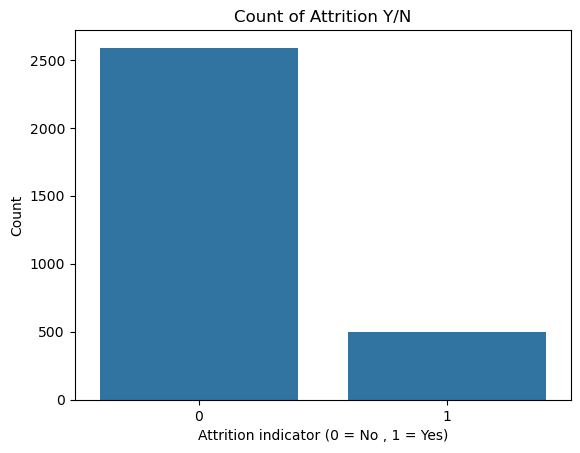

In [ ]:
#### --------------------- ####

sns.countplot(data = attrition_train, x = 'Attrition_lab')
plt.xlabel('Attrition indicator (0 = No , 1 = Yes)')
plt.ylabel('Count')
plt.title('Count of Attrition Y/N')
plt.show()

#### --------------------- ####

In [61]:
marginal_attrition_train = attrition_train['Attrition_lab'].value_counts(normalize=True)
marginal_attrition_train

Attrition_lab
0    0.838678
1    0.161322
Name: proportion, dtype: float64

#### after train testsplit same distribution of Y/N for Attrition

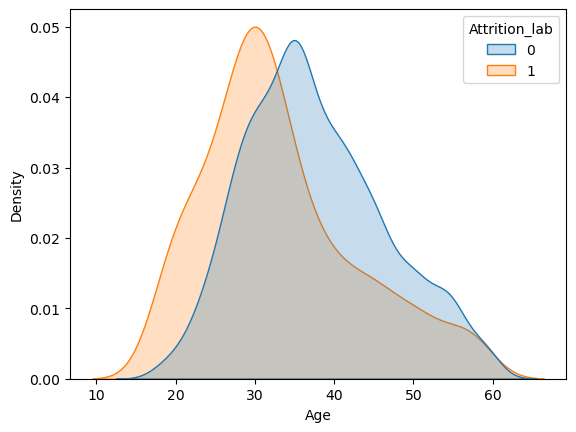

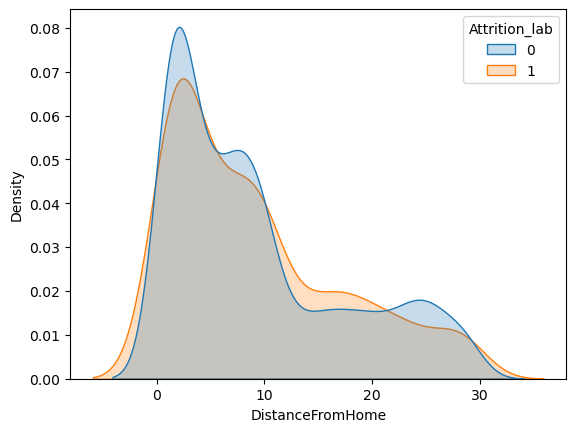

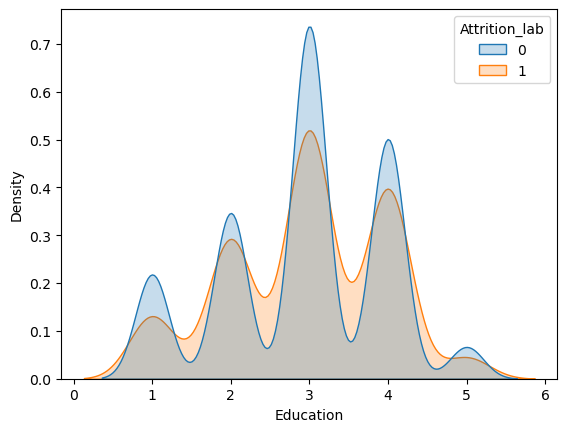

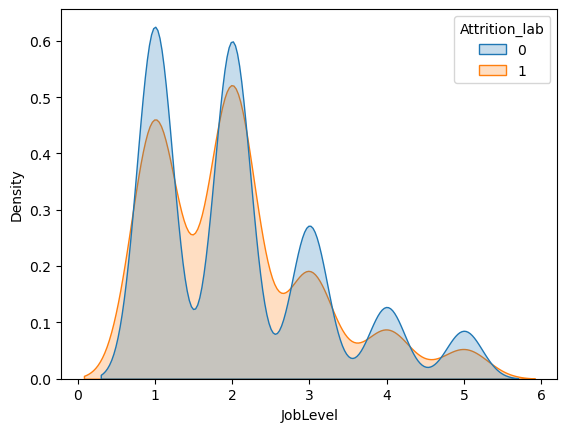

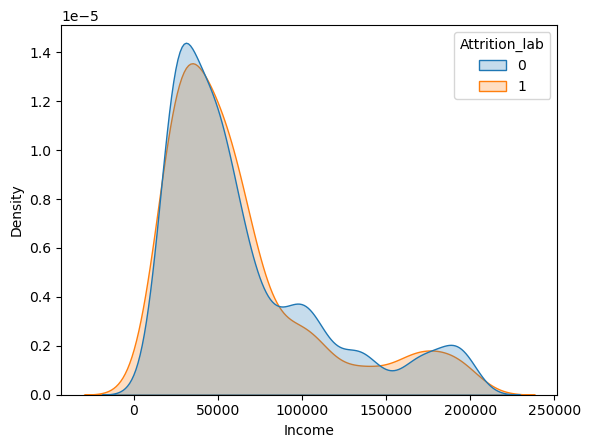

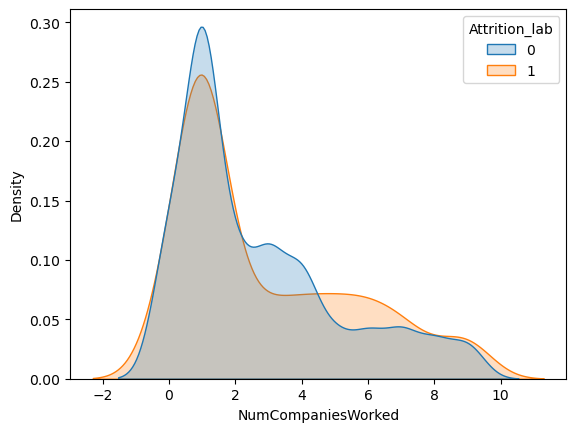

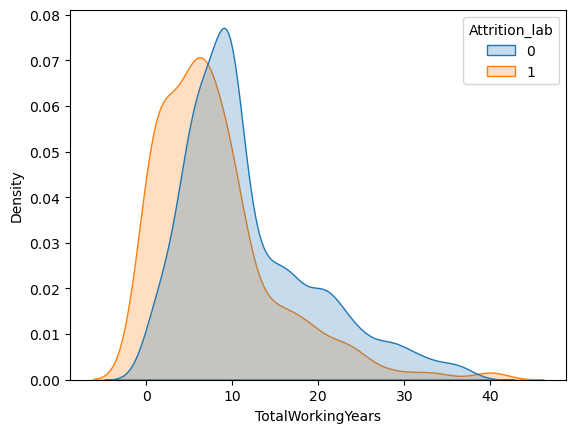

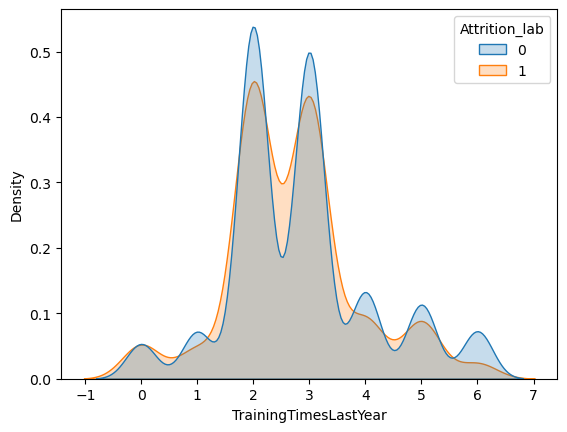

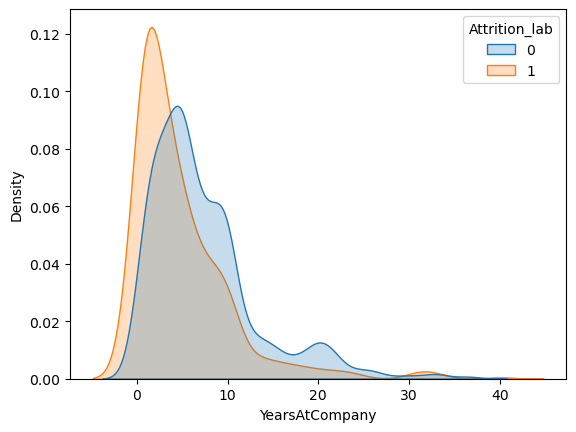

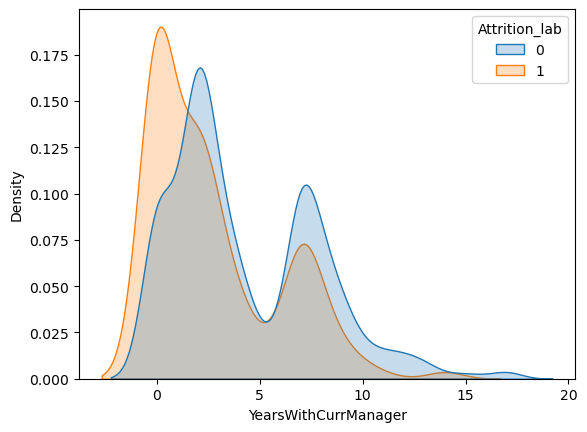

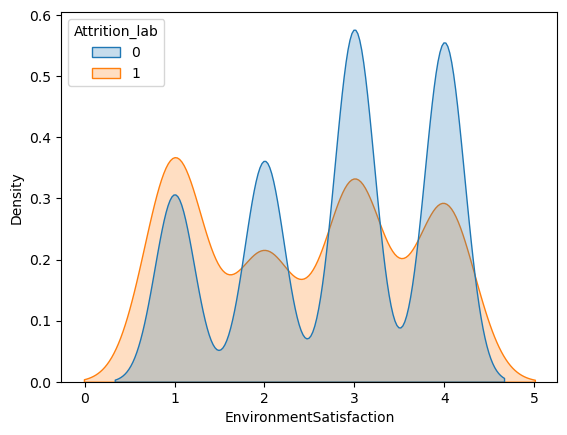

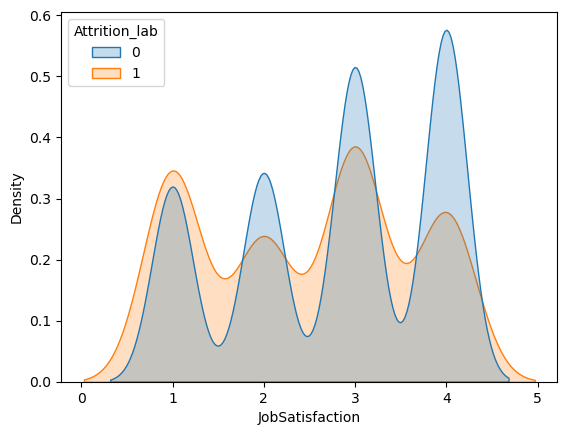

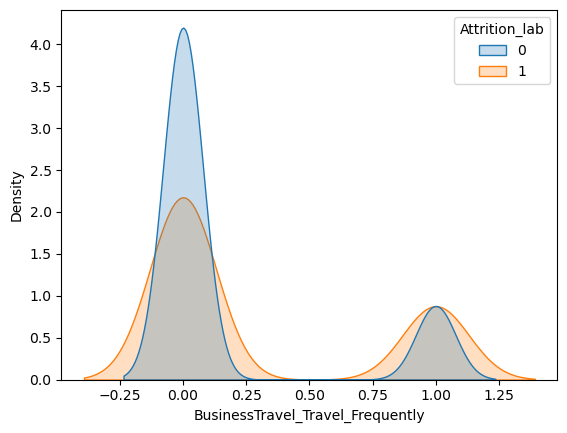

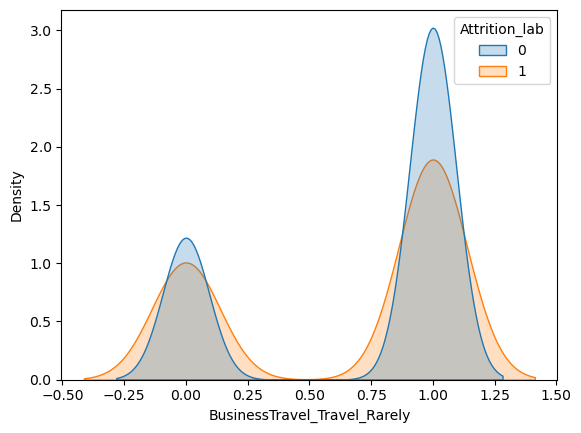

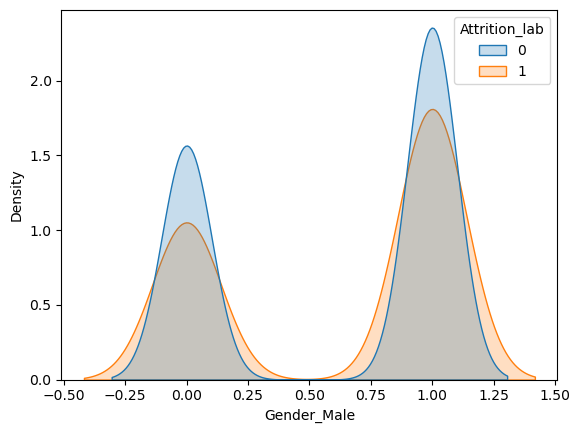

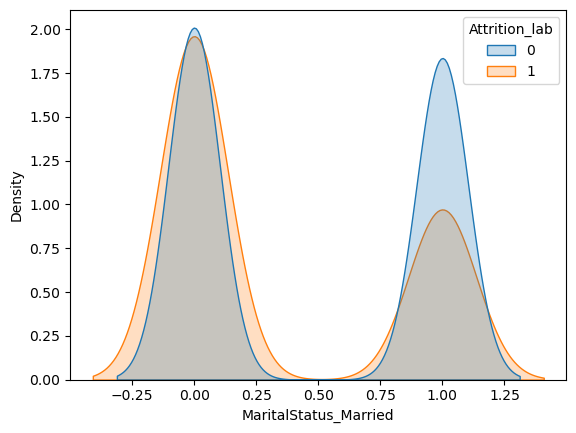

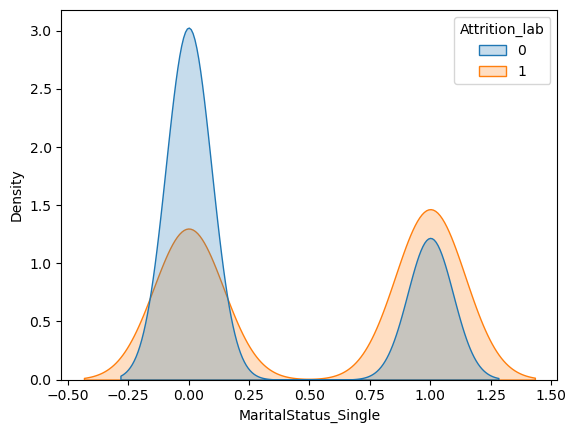

In [62]:
all_features = ['Age', 'DistanceFromHome', 'Education',
'JobLevel', 'Income', 'NumCompaniesWorked','TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'BusinessTravel_Travel_Frequently',
'BusinessTravel_Travel_Rarely', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single']

for i in all_features:
    sns.kdeplot(
        data = attrition_train,
        x = i,
        hue = 'Attrition_lab',
        fill = True,
        common_norm = False
    )   
    plt.show()

In [ ]:
sns.pairplot(
    attrition_train,
    hue ='Attrition_lab',
    diag_kind = 'kde'
)
plt.show()

#### Based on the above countplot and the density plots we can see that the dataset is highly imbalanced
- there is roughly 16% to 84% distribution of Yes/No for Attrition, respectively
- will need to rebalance the dataset (downsample)

---

#### to ensure reproducibility of our downsampling a random seed of 42 will be used

In [64]:
np.random.seed(42)

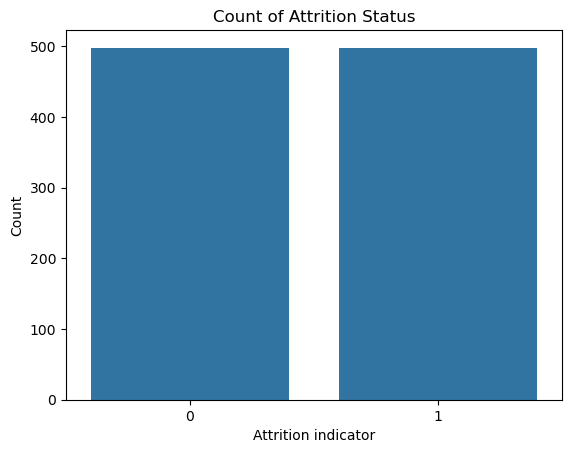

In [65]:
# Class imbalance: downsample the negative class; keep all positives
# + equal number of negatives

pos_idx = attrition_train.index[attrition_train["Attrition_lab"] == 1]
neg_idx = attrition_train.index[attrition_train["Attrition_lab"] == 0]

keep_neg = np.random.choice(neg_idx, size=len(pos_idx), replace=False)
keep_idx = np.concatenate([pos_idx, keep_neg])

attrition_train_bal = attrition_train.loc[keep_idx].copy()

# Quick look after balancing
sns.countplot(data = attrition_train_bal, x="Attrition_lab")
plt.xlabel("Attrition indicator")
plt.ylabel("Count")
plt.title("Count of Attrition Status")
plt.show()

In [66]:
marginal_attrition_train_bal = attrition_train_bal['Attrition_lab'].value_counts(normalize=True)
marginal_attrition_train_bal

Attrition_lab
1    0.5
0    0.5
Name: proportion, dtype: float64

#### After balancing the dataset by downsampling, the attrition distribution was normalized

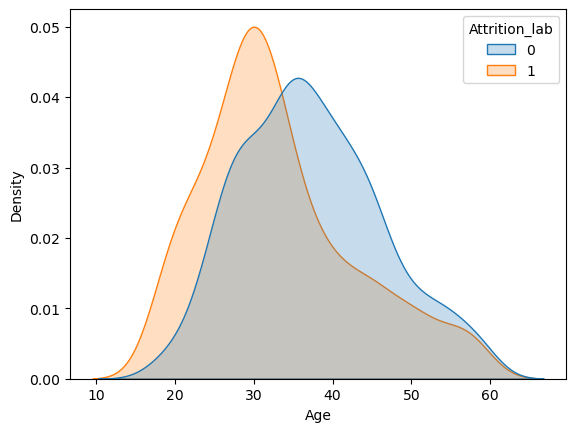

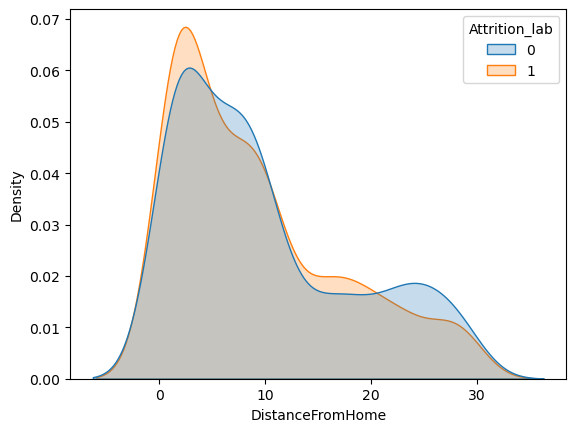

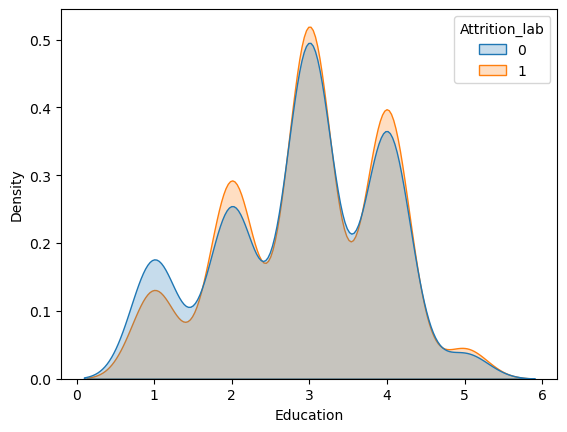

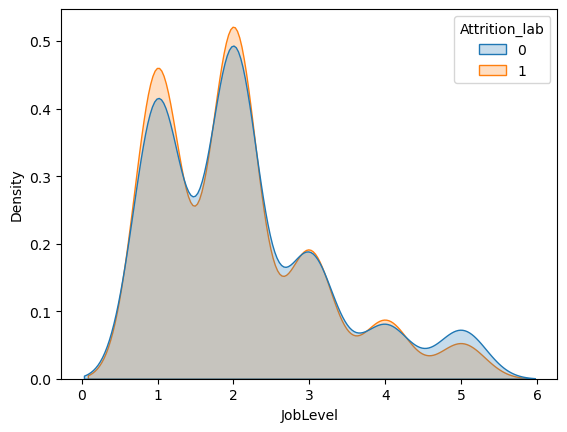

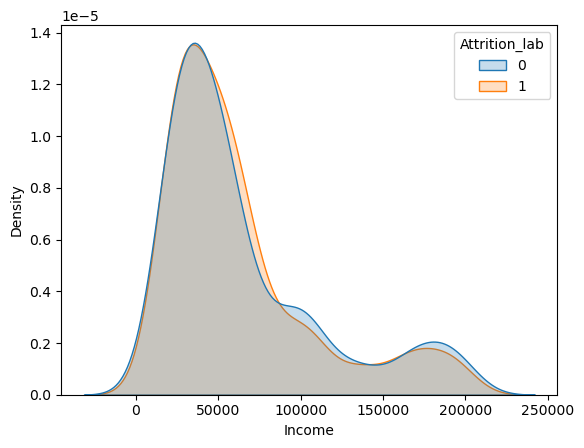

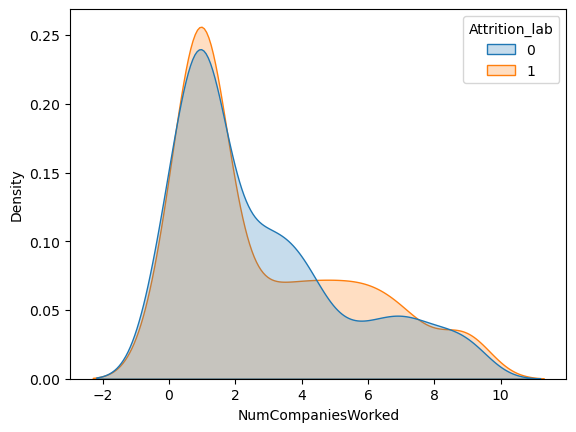

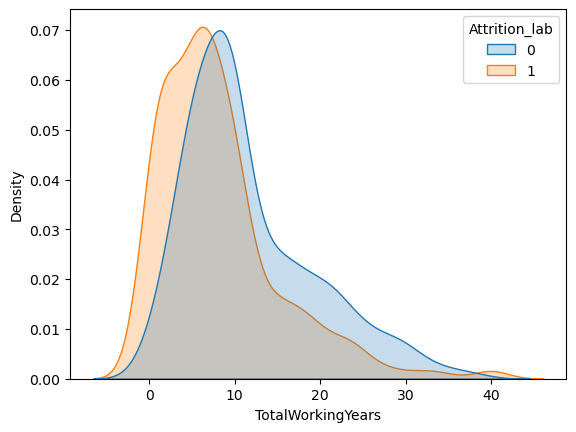

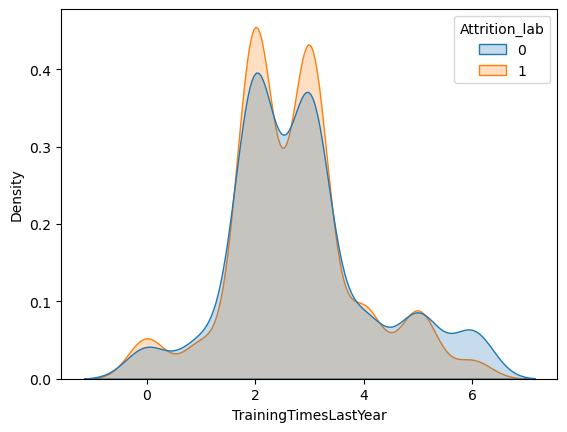

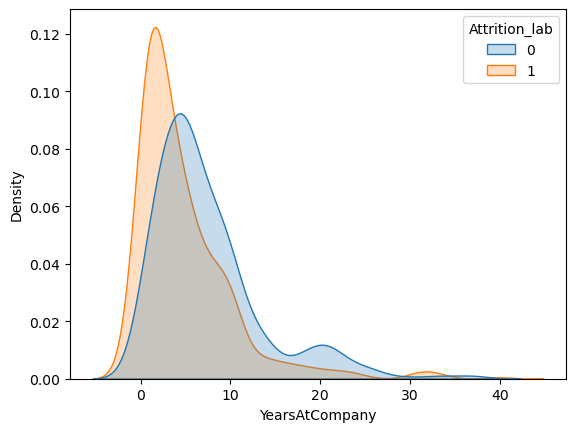

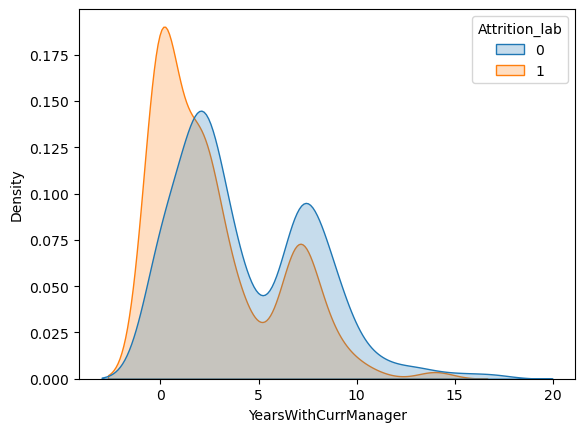

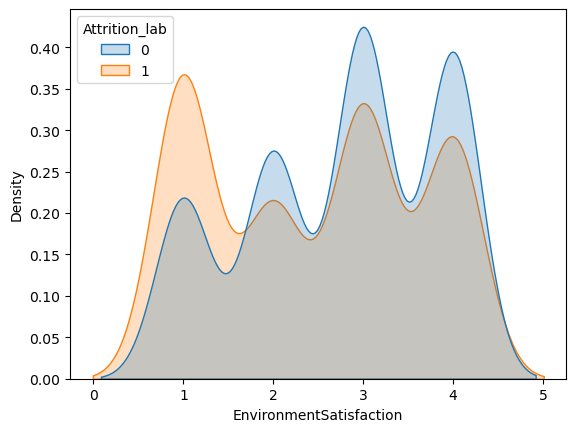

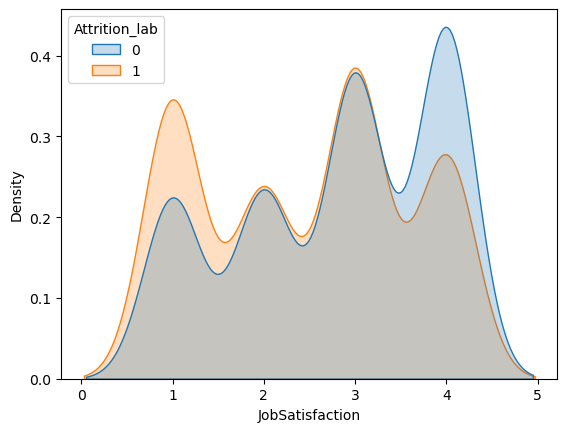

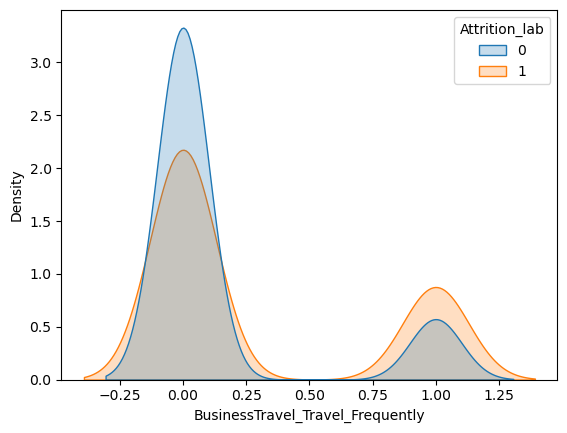

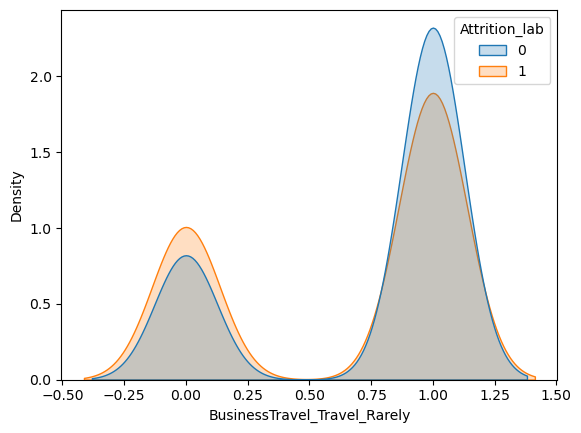

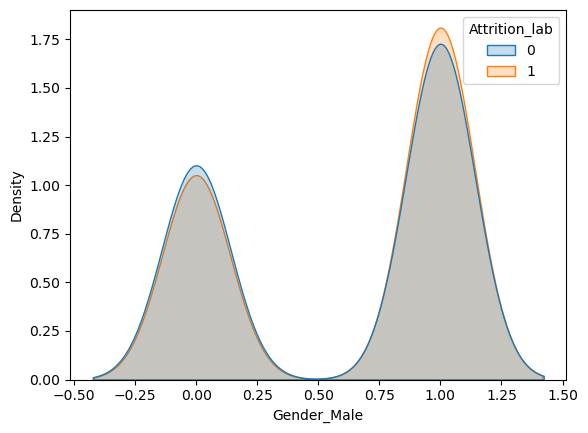

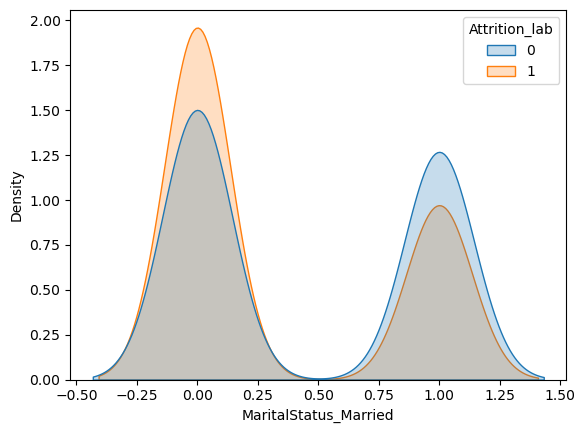

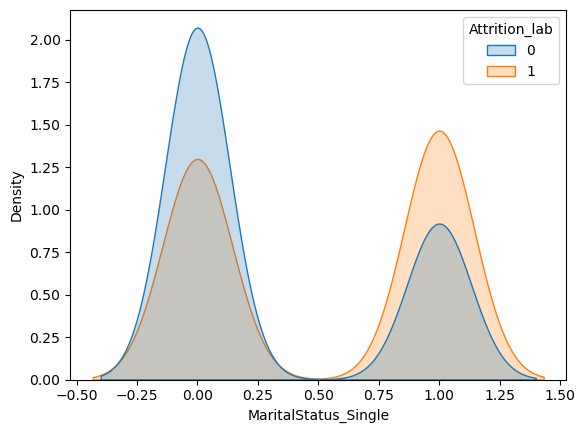

In [67]:
all_features = ['Age', 'DistanceFromHome', 'Education',
'JobLevel', 'Income', 'NumCompaniesWorked','TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'BusinessTravel_Travel_Frequently',
'BusinessTravel_Travel_Rarely', 'Gender_Male', 'MaritalStatus_Married', 'MaritalStatus_Single']

for i in all_features:
    sns.kdeplot(
        data = attrition_train_bal,
        x = i,
        hue = 'Attrition_lab',
        fill = True,
        common_norm = False
    )   
    plt.show()

---

#### Q2 Model Comparison - Choose four variables from the list provided (e.g., `Age`, `Gender`, `JobSatisfaction`, `Income`) and use them to create logistic regression models with the following combinations:
- Model 1: A one-variable model with `Age`.
- Model 2: A two-variable model with `Age` and `Gender`
- Model 3: A three-variable model with `Age`, `Gender`, and `JobSatisfaction`.
- Model 4: An interaction model involving `Age`, `Gender`, `JobSatisfaction`, `Income`, and `Gender:Income`. 
- Compare the validation-set performance of these models using the following metrics: AIC, AUC, Precision & Recall (use p = 0.5 as cutoff). Include tables summarizing the results. 
 Create a graph to visually represent the comparison of the models based on the selected metrics. 

#### the first step is to define the features needed for this model

#### Need to create some age bins
- will create a simple model based on the KDE plots where there seems to be a disconnect at 35 
- additionally will create a more complex model to explore many different age bins (25-35-45-55)


In [68]:
#### simple model: Unbalanced Dataset 
attrition_train['Age_simple'] = pd.cut(attrition_train['Age'], bins = [0, 35, 100] , labels=['35 and Younger' , 'Over 35'] )
simple_age_table = pd.crosstab(attrition_train['Age_simple'], attrition_train['Attrition_lab'])
print(simple_age_table)
attrition_train['Age_simple_lab'] = (attrition_train['Age_simple'] == "35 and Younger").astype(int)


Attrition_lab      0    1
Age_simple               
35 and Younger  1182  342
Over 35         1407  156


In [69]:
#### simple model: Balanced Dataset 
attrition_train_bal['Age_simple'] = pd.cut(attrition_train_bal['Age'], bins = [0, 35, 100] , labels=['35 and Younger' , 'Over 35'] )
simple_age_table_bal = pd.crosstab(attrition_train_bal['Age_simple'], attrition_train_bal['Attrition_lab'])
print(simple_age_table_bal)
### now need to convert these ages to binary
attrition_train_bal['Age_simple_lab'] = (attrition_train_bal['Age_simple'] == "35 and Younger").astype(int)


Attrition_lab     0    1
Age_simple              
35 and Younger  230  342
Over 35         268  156


In [70]:
#### need to create this new column for the test set as well
attrition_test['Age_simple'] = pd.cut(attrition_test['Age'], bins = [0, 35, 100] , labels=['35 and Younger' , 'Over 35'] )
attrition_test['Age_simple_lab'] = (attrition_test['Age_simple'] == "35 and Younger").astype(int)

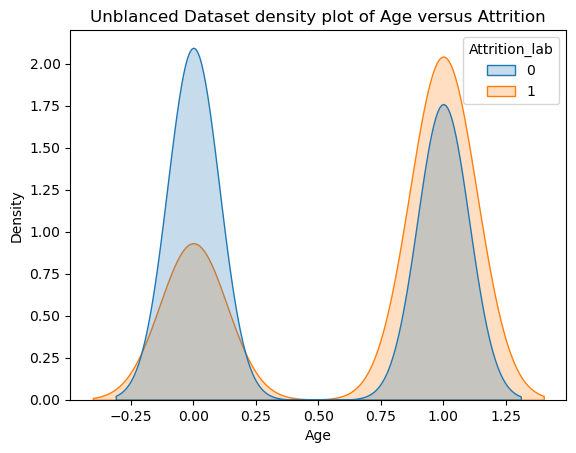

In [ ]:
#### -------------------------------------------- ####

sns.kdeplot(
        data = attrition_train,
        x = 'Age_simple_lab',
        hue = 'Attrition_lab',
        fill = True,
        common_norm = False
    )   
plt.title('Unblanced Dataset density plot of Age versus Attrition')
plt.xlabel('Age')
plt.show()

#### -------------------------------------------- ####


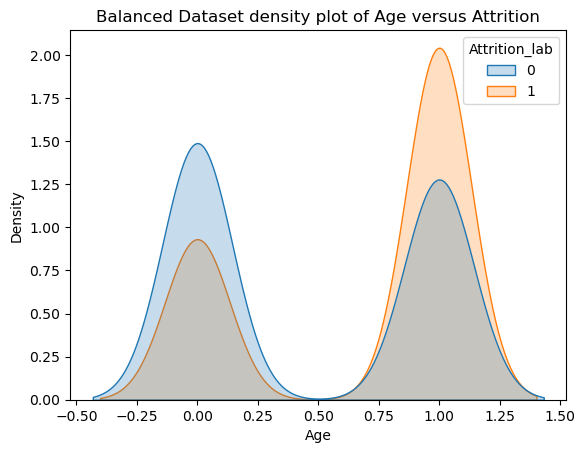

In [ ]:
#### -------------------------------------------- ####


sns.kdeplot(
        data = attrition_train_bal,
        x = 'Age_simple_lab',
        hue = 'Attrition_lab',
        fill = True,
        common_norm = False
    )   
plt.title('Balanced Dataset density plot of Age versus Attrition')
plt.xlabel('Age')
plt.show()

#### -------------------------------------------- ####


#### Need to finish complex if the simple does not work

In [73]:
#### detailed/complex (In progress)


In [74]:
model_1_features = ['Age']
model_1_features_update = ['Age_simple_lab']
model_2_features = ['Age', 'Gender_Male']
model_2_features_update = ['Age_simple_lab', 'Gender_Male']
model_3_features = ['Age' , 'Gender_Male' , 'JobSatisfaction']
model_3_features_update = ['Age_simple_lab' , 'Gender_Male' , 'JobSatisfaction']
## need to create a new column for Gender:Income (need to do this for both our balanced train set and our X_test_encoded)

attrition_train_bal['Gender:Income'] = attrition_train_bal['Income'] * attrition_train_bal['Gender_Male']
attrition_train['Gender:Income'] = attrition_train['Income'] * attrition_train['Gender_Male']
attrition_test['Gender:Income'] = attrition_test['Income'] * attrition_test['Gender_Male']

model_4_features = ['Age' , 'Gender_Male' , 'JobSatisfaction' , 'Income' , 'Gender:Income' ]
model_4_features_update = ['Age_simple_lab' , 'Gender_Male' , 'JobSatisfaction' , 'Income' , 'Gender:Income' ]


#### additionally create a predictor column (drop the employee id column , attrition , and work hours columns)

In [75]:
predictors = attrition_train_bal.columns.tolist()
### need to remove Attrition, EmployeeID , StandardHours , Attrition_lab
predictors.remove('Attrition_lab')
predictors.remove('Age')
predictors.remove('Age_simple')
predictors.remove('Attrition')
predictors.remove('EmployeeID')
predictors.remove('StandardHours')
predictors


['DistanceFromHome',
 'Education',
 'JobLevel',
 'Income',
 'NumCompaniesWorked',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsWithCurrManager',
 'EnvironmentSatisfaction',
 'JobSatisfaction',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Gender_Male',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Age_simple_lab',
 'Gender:Income']

#### Create the models 
- first we will create the models 
- Also will create a model with all the predictors

---

#### Create a function to run each base model

In [76]:
def log_reg_summary(df, response, predictors): 
    model = sm.Logit(df[response], sm.add_constant(df[predictors])).fit()
    print(f"\n=== f1 summary ({len(predictors)} features)===")
    print(model.summary())
    return model


---

#### Model 1

In [77]:
print('Unbalanced')
model1_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_1_features)
print('=' * 80)
print('=' * 80)
print('=' * 80)
print('Balanced')
model1 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_1_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.424761
         Iterations 6

=== f1 summary (1 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3085
Method:                           MLE   Df Model:                            1
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.03869
Time:                        22:15:08   Log-Likelihood:                -1311.2
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 9.299e-25
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4516      0.213      2.124      0.034       0.03

In [78]:
print('Unbalanced with updated age feature')
model1a_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_1_features_update)
print('=' * 80)
print('=' * 80)
print('=' * 80)
print('Balanced with updated age feature')
model1a = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_1_features_update)


Unbalanced with updated age feature
Optimization terminated successfully.
         Current function value: 0.427234
         Iterations 6

=== f1 summary (1 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3085
Method:                           MLE   Df Model:                            1
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.03309
Time:                        22:15:08   Log-Likelihood:                -1318.9
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 2.079e-21
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.1994      0

---

#### Model 2

In [79]:
print('Unbalanced')
model2_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_2_features)
print('=================================================================================')
print('=================================================================================')
print('=================================================================================')
print('Balanced')
model2 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_2_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.424663
         Iterations 6

=== f1 summary (2 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3084
Method:                           MLE   Df Model:                            2
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.03891
Time:                        22:15:08   Log-Likelihood:                -1310.9
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 8.931e-24
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3929      0.226      1.742      0.082      -0

In [80]:
print('Unbalanced with updated age feature')
model2a_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_2_features_update)
print('=' * 80)
print('=' * 80)
print('=' * 80)
print('Balanced with updated age feature')
model2a = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_2_features_update)


Unbalanced with updated age feature
Optimization terminated successfully.
         Current function value: 0.427040
         Iterations 6

=== f1 summary (2 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3084
Method:                           MLE   Df Model:                            2
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.03353
Time:                        22:15:08   Log-Likelihood:                -1318.3
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 1.373e-20
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.2671      0

----

#### Model 3

In [81]:
print('Unbalanced')
model3_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_3_features)
print('=================================================================================')
print('=================================================================================')
print('=================================================================================')
print('Balanced')
model3 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_3_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.419795
         Iterations 6

=== f1 summary (3 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3083
Method:                           MLE   Df Model:                            3
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.04993
Time:                        22:15:08   Log-Likelihood:                -1295.9
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 2.496e-29
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.0459      0.256      4.088      0

In [82]:
print('Unbalanced with updated age feature')
model3a_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_3_features_update)
print('=' * 80)
print('=' * 80)
print('=' * 80)
print('Balanced with updated age feature')
model3a = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_3_features_update)


Unbalanced with updated age feature
Optimization terminated successfully.
         Current function value: 0.422247
         Iterations 6

=== f1 summary (3 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3083
Method:                           MLE   Df Model:                            3
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.04438
Time:                        22:15:08   Log-Likelihood:                -1303.5
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 4.559e-26
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.6408    

---

#### Model 4

In [83]:
print('Unbalanced')
model4_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_4_features)
print('=================================================================================')
print('=================================================================================')
print('=================================================================================')
print('Balanced')
model4 = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_4_features)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.419353
         Iterations 6

=== f1 summary (5 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3081
Method:                           MLE   Df Model:                            5
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.05093
Time:                        22:15:08   Log-Likelihood:                -1294.5
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 3.021e-28
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.2047      0.284      4.249      0

In [84]:
print('Unbalanced with updated age feature')
model4a_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , model_4_features_update)
print('=' * 80)
print('=' * 80)
print('=' * 80)
print('Balanced with updated age feature')
model4a = log_reg_summary(attrition_train_bal , 'Attrition_lab' , model_4_features_update)


Unbalanced with updated age feature
Optimization terminated successfully.
         Current function value: 0.421960
         Iterations 6

=== f1 summary (5 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3081
Method:                           MLE   Df Model:                            5
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.04503
Time:                        22:15:08   Log-Likelihood:                -1302.6
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 7.892e-25
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.5146    

---

#### All predictors

In [85]:
print('Unbalanced')
model_all_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , predictors)
print('=================================================================================')
print('=================================================================================')
print('=================================================================================')
print('Balanced')
model_all = log_reg_summary(attrition_train_bal , 'Attrition_lab' , predictors)

Unbalanced
Optimization terminated successfully.
         Current function value: 0.375179
         Iterations 7

=== f1 summary (18 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3068
Method:                           MLE   Df Model:                           18
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.1509
Time:                        22:15:08   Log-Likelihood:                -1158.2
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 3.378e-76
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const               

#### Down below we performed SFS and found 'NumCompaniesWorked','YearsAtCompany','YearsWithCurrManager', 'JobSatisfaction','BusinessTravel_Travel_Frequently','MaritalStatus_Single','Age_simple_lab' to be the best 7 predictors. 

In [86]:
selected_cols= ['NumCompaniesWorked','YearsAtCompany','YearsWithCurrManager',
                 'JobSatisfaction','BusinessTravel_Travel_Frequently','MaritalStatus_Single','Age_simple_lab']

In [87]:
print('Unbalanced')
model_SFS_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , selected_cols)
print('=================================================================================')
print('=================================================================================')
print('=================================================================================')
print('Balanced')
model_SFS = log_reg_summary(attrition_train_bal , 'Attrition_lab' , selected_cols)

Unbalanced
Optimization terminated successfully.
         Current function value: 0.387765
         Iterations 7

=== f1 summary (7 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3079
Method:                           MLE   Df Model:                            7
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.1224
Time:                        22:15:08   Log-Likelihood:                -1197.0
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 3.350e-68
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                

---

#### Parameter interpretation of SFS model

In [88]:
paramater_SFS = model_SFS.params
pvalues_SFS = model_SFS.pvalues
odds_ratios_SFS = np.exp(paramater_SFS)
SFS_values_df = pd.DataFrame({
    'Coefficient' : paramater_SFS, 
    'P Values' : pvalues_SFS, 
    'Odds Ratio' : odds_ratios_SFS
})

SFS_values_df



,Coefficient,P Values,Odds Ratio
const,-0.099881,6.982942e-01,0.904945
NumCompaniesWorked,0.084168,3.275004e-03,1.087812
YearsAtCompany,0.016346,4.107914e-01,1.016480
YearsWithCurrManager,-0.137186,6.065662e-05,0.871808
JobSatisfaction,-0.305073,1.696611e-06,0.737070
BusinessTravel_Travel_Frequently,0.890187,3.569982e-07,2.435586
MaritalStatus_Single,0.839238,3.797826e-09,2.314603
Age_simple_lab,0.878741,1.568061e-08,2.407867


- Based on the odds ratio we can determine that Age , Marital Status , Business Travel (positives that lead to attrition)
- In Contrast, Job satisfaction and Years with Current Manager are inversely related. (negatives)

In [89]:
pivot_df_sfs = SFS_values_df.reset_index().melt(
    id_vars= 'index', 
    var_name= 'Metric',
    value_name= 'Value'
)

pivot_df_sfs


,index,Metric,Value
0,const,Coefficient,-9.988058e-02
1,NumCompaniesWorked,Coefficient,8.416846e-02
2,YearsAtCompany,Coefficient,1.634552e-02
3,YearsWithCurrManager,Coefficient,-1.371860e-01
4,JobSatisfaction,Coefficient,-3.050728e-01
5,BusinessTravel_Travel_Frequently,Coefficient,8.901874e-01
6,MaritalStatus_Single,Coefficient,8.392383e-01
7,Age_simple_lab,Coefficient,8.787414e-01
8,const,P Values,6.982942e-01
9,NumCompaniesWorked,P Values,3.275004e-03


In [90]:
SFS_barplot = pivot_df_sfs[pivot_df_sfs['Metric']!= 'P Values']



In [ ]:
#### ************************************** ####

alt.Chart(SFS_barplot).mark_bar().encode(
    x=alt.X('Metric:N' , title = 'Performance Metric'),
    y = alt.Y('Value:Q', title = 'Score'), 
    color = alt.Color('index:N' , title = 'Model'),
    xOffset= 'index:N'
).properties(
    width = 800,
    height = 600
)

#### ************************************** ####


alt.Chart(...)

---

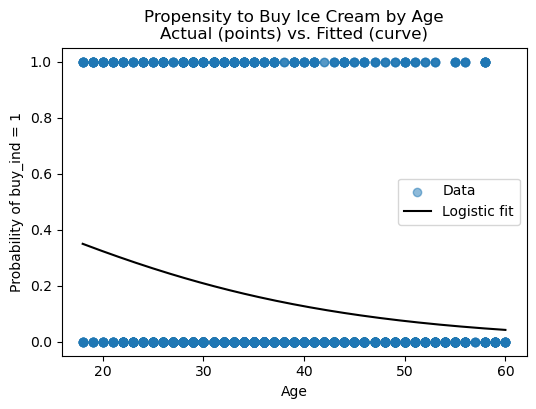

In [92]:
# -------------------------------------------------------------------
# Plot simple logistic fit
# -------------------------------------------------------------------

# Create evenly spaced values across the range of Age for a smooth curve
age_grid = np.linspace(attrition_train["Age"].min(), attrition_train["Age"].max(), 200)

pred_df = pd.DataFrame({"Age": age_grid})

# Predicted probabilities from the logistic model over evenly-spaced Age
p_hat = model1_unbalanced.predict(sm.add_constant(pred_df))


# scatter plot of actual age values
plt.figure(figsize=(6, 4))
plt.scatter(attrition_train["Age"], attrition_train["Attrition_lab"], alpha=0.5, label="Data")

# plot the logistic line
plt.plot(age_grid, p_hat, label="Logistic fit", color="black")

# add labels and show the plot
plt.xlabel("Age")
plt.ylabel("Probability of buy_ind = 1")
plt.title("Propensity to Buy Ice Cream by Age\nActual (points) vs. Fitted (curve)")
plt.legend()
plt.show()


Attrition indicator (0 = No , 1 = Yes)

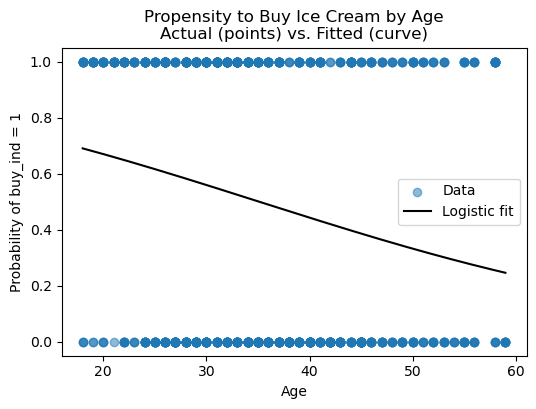

In [ ]:
#### ************************************** ####


# -------------------------------------------------------------------
# Plot simple logistic fit
# -------------------------------------------------------------------

# Create evenly spaced values across the range of Age for a smooth curve
age_grid = np.linspace(attrition_train_bal["Age"].min(), attrition_train_bal["Age"].max(), 200)

pred_df = pd.DataFrame({"Age": age_grid})

# Predicted probabilities from the logistic model over evenly-spaced Age
p_hat = model1.predict(sm.add_constant(pred_df))


# scatter plot of actual age values
plt.figure(figsize=(6, 4))
plt.scatter(attrition_train_bal["Age"], attrition_train_bal["Attrition_lab"], alpha=0.5, label="Data")

# plot the logistic line
plt.plot(age_grid, p_hat, label="Logistic fit", color="black")

# add labels and show the plot
plt.xlabel("Age")
plt.ylabel("Probability of buy_ind = 1")
plt.title("Propensity to Buy Ice Cream by Age\nActual (points) vs. Fitted (curve)")
plt.legend()
plt.show()

####   ************************************** ####

In [94]:
# -------------------------------------------------------------------
# Plot simple logistic fit
# -------------------------------------------------------------------

# Create evenly spaced values across the range of Age for a smooth curve
#age_grid = np.linspace(attrition_train_bal['Age'].min(), attrition_train_bal["Age"].max(), 200)

#pred_df = pd.DataFrame({'Age': age_grid})
## need to add all the features 
#pred_df = pred_df[selected_cols]

# Predicted probabilities from the logistic model over evenly-spaced Age
#p_hat = model_SFS.predict.proba((pred_df))[:,1]


# scatter plot of actual age values
#plt.figure(figsize=(6, 4))
#plt.scatter(attrition_train_bal["Age"], attrition_train_bal["Attrition_lab"], alpha=0.5, label="Data")

# plot the logistic line
#plt.plot(age_grid, p_hat, label="Logistic fit", color="black")

# add labels and show the plot
#plt.xlabel("Age")
#plt.ylabel("Probability of buy_ind = 1")
#plt.title("Propensity to Buy Ice Cream by Age\nActual (points) vs. Fitted (curve)")
#plt.legend()
#plt.show()


In [95]:
'''
# -------------------------------------------------------------------
# Logistic vs Approximate Linear Marginal Effects
# -------------------------------------------------------------------


# Average marginal effect from logistic model
mfx_overall = logit_model.get_margeff(at="overall", method="dydx")

print("\nAverage marginal effects (logistic, overall):")
print(mfx_overall.summary())

avg_mfx_age = float(mfx_overall.margeff[0])
print(f"\nAverage marginal effect of Age on P(buy): {avg_mfx_age:.4f}")

# Plot logistic vs “avg marginal effect” line

# start with actual values
plt.figure(figsize=(6, 4))
plt.scatter(ice_cream_train["Age"], ice_cream_train["buy_ind"], alpha=0.5, label="Data")

# Logistic curve (black)
plt.plot(age_grid, p_hat, label="Logistic fit", color="black")


# “Avg marginal effect” line (red, dotted)
# For illustration: start at 1 when Age=0 and decrease at avg_mfx_age per year
mfx_line = 1 + avg_mfx_age * age_grid
plt.plot(age_grid, mfx_line, color="red", linestyle=":", label="Avg logit marginal effect line")

plt.xlabel("Age")
plt.ylabel("Probability / Indicator")
plt.title("Propensity to Buy Ice Cream by Age\n"
          "Logistic (black) vs Avg Logit Mfx (red)")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()


'''


'\n# -------------------------------------------------------------------\n# Logistic vs Approximate Linear Marginal Effects\n# -------------------------------------------------------------------\n\n\n# Average marginal effect from logistic model\nmfx_overall = logit_model.get_margeff(at="overall", method="dydx")\n\nprint("\nAverage marginal effects (logistic, overall):")\nprint(mfx_overall.summary())\n\navg_mfx_age = float(mfx_overall.margeff[0])\nprint(f"\nAverage marginal effect of Age on P(buy): {avg_mfx_age:.4f}")\n\n# Plot logistic vs “avg marginal effect” line\n\n# start with actual values\nplt.figure(figsize=(6, 4))\nplt.scatter(ice_cream_train["Age"], ice_cream_train["buy_ind"], alpha=0.5, label="Data")\n\n# Logistic curve (black)\nplt.plot(age_grid, p_hat, label="Logistic fit", color="black")\n\n\n# “Avg marginal effect” line (red, dotted)\n# For illustration: start at 1 when Age=0 and decrease at avg_mfx_age per year\nmfx_line = 1 + avg_mfx_age * age_grid\nplt.plot(age_grid, 

---

# VIF Table to explore multicolinearity
#### now that we have gotten the base models, we can produce a VIF table to explore the VIF values for each variable

In [96]:
def vif_table(model):
    X = model.model.exog
    names = model.model.exog_names
    vif_values = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return pd.DataFrame({"variable": names, "VIF": vif_values})

In [97]:
### helper function to print results of all the models
def print_vif(f1):
    vif_df = vif_table(f1)
    return vif_df

---

#### Model 1

In [98]:
print('Unbalanced')
print_vif(model1_unbalanced)

Unbalanced


,variable,VIF
0,const,17.295005
1,Age,1.000000


In [99]:
print('Balanced')
print_vif(model1)

Balanced


,variable,VIF
0,const,14.474254
1,Age,1.000000


In [100]:
print('Unbalanced with age bin update')
print_vif(model1a_unbalanced)

Unbalanced with age bin update


,variable,VIF
0,const,1.975048
1,Age_simple_lab,1.000000


In [101]:
print('Balanced with age bin update')
print_vif(model1a)

Balanced with age bin update


,variable,VIF
0,const,2.349057
1,Age_simple_lab,1.000000


---

#### Model 2

In [102]:
print('Unbalanced')
print_vif(model2_unbalanced)

Unbalanced


,variable,VIF
0,const,19.387184
1,Age,1.002585
2,Gender_Male,1.002585


In [103]:
print('Balanced')
print_vif(model2)

Balanced


,variable,VIF
0,const,16.391562
1,Age,1.000784
2,Gender_Male,1.000784


In [104]:
print('Unbalanced with age bin update')
print_vif(model2a_unbalanced)

Unbalanced with age bin update


,variable,VIF
0,const,3.445923
1,Age_simple_lab,1.000762
2,Gender_Male,1.000762


In [105]:
print('Balanced with age bin update')
print_vif(model2a)

Balanced with age bin update


,variable,VIF
0,const,3.984624
1,Age_simple_lab,1.000005
2,Gender_Male,1.000005


---

### Model 3

In [106]:
print('Unbalanced')
print_vif(model3_unbalanced)

Unbalanced


,variable,VIF
0,const,25.336113
1,Age,1.002587
2,Gender_Male,1.002877
3,JobSatisfaction,1.000291


In [107]:
print('Balanced')
print_vif(model3)

Balanced


,variable,VIF
0,const,21.567015
1,Age,1.001646
2,Gender_Male,1.001043
3,JobSatisfaction,1.001147


In [108]:
print('Unbalanced with age bin update')
print_vif(model3a_unbalanced)

Unbalanced with age bin update


,variable,VIF
0,const,9.443250
1,Age_simple_lab,1.000795
2,Gender_Male,1.001057
3,JobSatisfaction,1.000322


In [109]:
print('Balanced with age bin update')
print_vif(model3a)

Balanced with age bin update


,variable,VIF
0,const,9.806533
1,Age_simple_lab,1.000647
2,Gender_Male,1.000288
3,JobSatisfaction,1.000928


---

### Model 4

In [110]:
print('Unbalanced')
print_vif(model4_unbalanced)


Unbalanced


,variable,VIF
0,const,30.187354
1,Age,1.004074
2,Gender_Male,2.879782
3,JobSatisfaction,1.000493
4,Income,2.519750
5,Gender:Income,4.413888


In [111]:
print('Balanced')
print_vif(model4)

Balanced


,variable,VIF
0,const,27.328381
1,Age,1.007149
2,Gender_Male,2.802620
3,JobSatisfaction,1.004053
4,Income,2.682941
5,Gender:Income,4.547281


In [112]:
print('Unbalanced with age bin update')
print_vif(model4a_unbalanced)

Unbalanced with age bin update


,variable,VIF
0,const,14.063398
1,Age_simple_lab,1.000805
2,Gender_Male,2.879535
3,JobSatisfaction,1.000525
4,Income,2.519451
5,Gender:Income,4.412930


In [113]:
print('Balanced with age bin update')
print_vif(model4a)

Balanced with age bin update


,variable,VIF
0,const,14.873814
1,Age_simple_lab,1.003495
2,Gender_Male,2.802650
3,JobSatisfaction,1.003799
4,Income,2.684462
5,Gender:Income,4.545281


----

#### All Features Model

In [114]:
print('Unbalanced')
print_vif(model_all_unbalanced)


Unbalanced


,variable,VIF
0,const,61.115963
1,DistanceFromHome,1.012245
2,Education,1.008687
3,JobLevel,1.013287
4,Income,2.551052
5,NumCompaniesWorked,1.256764
6,TotalWorkingYears,2.437371
7,TrainingTimesLastYear,1.015723
8,YearsAtCompany,3.372728
9,YearsWithCurrManager,2.458314


In [115]:
print('Balanced')
print_vif(model_all)

Balanced


,variable,VIF
0,const,63.846814
1,DistanceFromHome,1.037392
2,Education,1.016210
3,JobLevel,1.042099
4,Income,2.736527
5,NumCompaniesWorked,1.271390
6,TotalWorkingYears,3.072397
7,TrainingTimesLastYear,1.040093
8,YearsAtCompany,3.927741
9,YearsWithCurrManager,2.582173


---

#### ROC / AUC / Precision / Recall
- test balanced/unbalanced trained dataset

#### Create a helper function to evaulate the models

In [116]:
def evaulate_model(df , model , response, predictors, score):
    train_probs = model.predict(sm.add_constant(df[predictors]))
    train_pred_class = (train_probs >= score).astype(int)
    cm_train = confusion_matrix(df[response] , train_pred_class)
    precision_train = precision_score(df[response] , train_pred_class)
    recall_train = recall_score(df[response] , train_pred_class)
    print("\nIn-sample confusion matrix (threshold = 0.5):")
    dataframe = pd.DataFrame(
        cm_train,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )
    print(f"\nPrecision (train): {precision_train:.3f}")
    print(f"Recall (train):    {recall_train:.3f}")
    return dataframe

---

#### Model 1 Comparision

In [117]:
print('Unbalanced')
evaulate_model(attrition_train , model1_unbalanced , 'Attrition_lab',
               model_1_features , 0.5)

Unbalanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


c:\Users\liula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


In [118]:
print('Balanced')
evaulate_model(attrition_train_bal , model1 , 'Attrition_lab',
               model_1_features , 0.5)

Balanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.598
Recall (train):    0.687


,Pred 0,Pred 1
Actual 0,268,230
Actual 1,156,342


---

#### Model 2 Comparision

In [119]:
print('Unbalanced')
evaulate_model(attrition_train , model2_unbalanced , 'Attrition_lab',
               model_2_features , 0.5)

Unbalanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


c:\Users\liula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


In [120]:
print('Balanced')
evaulate_model(attrition_train_bal , model2 , 'Attrition_lab',
               model_2_features , 0.5)

Balanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.610
Recall (train):    0.675


,Pred 0,Pred 1
Actual 0,283,215
Actual 1,162,336


---

#### Model 3 Comparision

In [121]:
print('Unbalanced')
evaulate_model(attrition_train , model3_unbalanced , 'Attrition_lab',
               model_3_features , 0.5)

Unbalanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


c:\Users\liula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


In [122]:
print('Balanced')
evaulate_model(attrition_train_bal , model3 , 'Attrition_lab',
               model_3_features , 0.5)

Balanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.621
Recall (train):    0.631


,Pred 0,Pred 1
Actual 0,306,192
Actual 1,184,314


---

#### Model 4 Comparision

In [123]:
print('Unbalanced')
evaulate_model(attrition_train , model4_unbalanced , 'Attrition_lab',
               model_4_features , 0.5)

Unbalanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


c:\Users\liula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred 0,Pred 1
Actual 0,2589,0
Actual 1,498,0


In [124]:
print('Balanced')
evaulate_model(attrition_train_bal , model4 , 'Attrition_lab',
               model_4_features , 0.5)

Balanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.618
Recall (train):    0.635


,Pred 0,Pred 1
Actual 0,303,195
Actual 1,182,316


---

#### All Predictors Model Comparision

In [125]:
print('Unbalanced')
evaulate_model(attrition_train , model_all_unbalanced , 'Attrition_lab',
               predictors , 0.5)

Unbalanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.724
Recall (train):    0.153


,Pred 0,Pred 1
Actual 0,2560,29
Actual 1,422,76


In [126]:
print('Balanced')
evaulate_model(attrition_train_bal , model_all , 'Attrition_lab',
               predictors , 0.5)

Balanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.699
Recall (train):    0.705


,Pred 0,Pred 1
Actual 0,347,151
Actual 1,147,351


---

#### compare the models against the test set to compare the validation-set performace of these models using AIC/AUC/Precision and recall

In [127]:
## create a helper function to help us compare against the test set

def test_metrics(model, features): 
    probs = model.predict(sm.add_constant(attrition_test[features]))
    preds = (probs >= 0.5).astype(int)
    auc=roc_auc_score(attrition_test['Attrition_lab'] , probs)
    prec = precision_score(attrition_test['Attrition_lab'], preds , zero_division= 0)
    rec = recall_score(attrition_test['Attrition_lab'], preds)
    return auc, prec, rec


In [128]:
auc_results =[]
### model 1 unbalanced
auc1u, prec1u, rec1u = test_metrics(model1_unbalanced, model_1_features)
auc_results.append({
    'Model': 'Model 1 Unbalanced',
    'Features': model_1_features,
    'AIC': round(model1_unbalanced.aic, 2),
    'AUC': round(auc1u, 4),
    'Precision': round(prec1u, 4),
    'Recall': round(rec1u, 4)})
### model 1 balanced
auc1b, prec1b, rec1b = test_metrics(model1, model_1_features)
auc_results.append({
    'Model': 'Model 1 Balanced',
    'Features': model_1_features,
    'AIC': round(model1.aic, 2),
    'AUC': round(auc1b, 4),
    'Precision': round(prec1b, 4),
    'Recall': round(rec1b, 4)})
## model 1 unbalanced age binary
auc1ua, prec1ua, rec1ua = test_metrics(model1a_unbalanced, model_1_features_update)
auc_results.append({
    'Model': 'Model 1 Unbalanced, Age Binary',
    'Features': model_1_features_update,
    'AIC': round(model1a_unbalanced.aic, 2),
    'AUC': round(auc1ua, 4),
    'Precision': round(prec1ua, 4),
    'Recall': round(rec1ua, 4)})
### model 1 balanced age binary
auc1ba, prec1ba, rec1ba = test_metrics(model1a, model_1_features_update)
auc_results.append({
    'Model': 'Model 1 Balanced , Age Binary',
    'Features': model_1_features_update,
    'AIC': round(model1a.aic, 2),
    'AUC': round(auc1ba, 4),
    'Precision': round(prec1ba, 4),
    'Recall': round(rec1ba, 4)})
### model 2 unbalanced
auc2u, prec2u, rec2u = test_metrics(model2_unbalanced, model_2_features)
auc_results.append({
    'Model': 'Model 2 Unbalanced',
    'Features': model_2_features,
    'AIC': round(model2_unbalanced.aic, 2),
    'AUC': round(auc2u, 4),
    'Precision': round(prec2u, 4),
    'Recall': round(rec2u, 4)})
### model 2 balanced
auc2b, prec2b, rec2b = test_metrics(model2, model_2_features)
auc_results.append({
    'Model': 'Model 2 Balanced',
    'Features': model_2_features,
    'AIC': round(model2.aic, 2),
    'AUC': round(auc2b, 4),
    'Precision': round(prec2b, 4),
    'Recall': round(rec2b, 4)})

## model 1 unbalanced age binary
auc2ua, prec2ua, rec2ua = test_metrics(model2a_unbalanced, model_2_features_update)
auc_results.append({
    'Model': 'Model 2 Unbalanced, Age Binary',
    'Features': model_2_features_update,
    'AIC': round(model2a_unbalanced.aic, 2),
    'AUC': round(auc2ua, 4),
    'Precision': round(prec2ua, 4),
    'Recall': round(rec2ua, 4)})
### model 2 balanced age binary
auc2ba, prec2ba, rec2ba = test_metrics(model2a, model_2_features_update)
auc_results.append({
    'Model': 'Model 2 Balanced , Age Binary',
    'Features': model_2_features_update,
    'AIC': round(model2a.aic, 2),
    'AUC': round(auc2ba, 4),
    'Precision': round(prec2ba, 4),
    'Recall': round(rec2ba, 4)})
### model 3 unbalanced
auc3u, prec3u, rec3u = test_metrics(model3_unbalanced, model_3_features)
auc_results.append({
    'Model': 'Model 3 Unbalanced',
    'Features': model_3_features,
    'AIC': round(model3_unbalanced.aic, 2),
    'AUC': round(auc3u, 4),
    'Precision': round(prec3u, 4),
    'Recall': round(rec3u, 4)})
### model 3 balanced
auc3b, prec3b, rec3b = test_metrics(model3, model_3_features)
auc_results.append({
    'Model': 'Model 3 Balanced',
    'Features': model_3_features,
    'AIC': round(model3.aic, 2),
    'AUC': round(auc3b, 4),
    'Precision': round(prec3b, 4),
    'Recall': round(rec3b, 4)})
## model 3 unbalanced age binary
auc3ua, prec3ua, rec3ua = test_metrics(model3a_unbalanced, model_3_features_update)
auc_results.append({
    'Model': 'Model 3 Unbalanced, Age Binary',
    'Features': model_3_features_update,
    'AIC': round(model3a_unbalanced.aic, 2),
    'AUC': round(auc3ua, 4),
    'Precision': round(prec3ua, 4),
    'Recall': round(rec3ua, 4)})
### model 1 balanced age binary
auc3ba, prec3ba, rec3ba = test_metrics(model3a, model_3_features_update)
auc_results.append({
    'Model': 'Model 3 Balanced , Age Binary',
    'Features': model_3_features_update,
    'AIC': round(model3a.aic, 2),
    'AUC': round(auc3ba, 4),
    'Precision': round(prec3ba, 4),
    'Recall': round(rec3ba, 4)})
### model 4 unbalanced
auc4u, prec4u, rec4u = test_metrics(model4_unbalanced, model_4_features)
auc_results.append({
    'Model': 'Model 4 Unbalanced',
    'Features': model_4_features,
    'AIC': round(model4_unbalanced.aic, 2),
    'AUC': round(auc4u, 4),
    'Precision': round(prec4u, 4),
    'Recall': round(rec4u, 4)})
### model 4 balanced
auc4b, prec4b, rec4b = test_metrics(model4, model_4_features)
auc_results.append({
    'Model': 'Model 4 Balanced',
    'Features': model_4_features,
    'AIC': round(model4.aic, 2),
    'AUC': round(auc4b, 4),
    'Precision': round(prec4b, 4),
    'Recall': round(rec4b, 4)})
## model 4 unbalanced age binary
auc4ua, prec4ua, rec4ua = test_metrics(model4a_unbalanced, model_4_features_update)
auc_results.append({
    'Model': 'Model 4 Unbalanced, Age Binary',
    'Features': model_4_features_update,
    'AIC': round(model4a_unbalanced.aic, 2),
    'AUC': round(auc4ua, 4),
    'Precision': round(prec4ua, 4),
    'Recall': round(rec4ua, 4)})
### model 4 balanced age binary
auc4ba, prec4ba, rec4ba = test_metrics(model4a, model_4_features_update)
auc_results.append({
    'Model': 'Model 4 Balanced , Age Binary',
    'Features': model_4_features_update,
    'AIC': round(model4a.aic, 2),
    'AUC': round(auc4ba, 4),
    'Precision': round(prec4ba, 4),
    'Recall': round(rec4ba, 4)})
### model all unbalanced
aucallu, precallu, recallu = test_metrics(model_all_unbalanced, predictors)
auc_results.append({
    'Model': 'Model All Unbalanced',
    'Features': predictors,
    'AIC': round(model_all_unbalanced.aic, 2),
    'AUC': round(aucallu, 4),
    'Precision': round(precallu, 4),
    'Recall': round(recallu, 4)})
### model all balanced
aucallb, precallb, recallb = test_metrics(model_all, predictors)
auc_results.append({
    'Model': 'Model All Balanced',
    'Features': predictors,
    'AIC': round(model_all.aic, 2),
    'AUC': round(aucallb, 4),
    'Precision': round(precallb, 4),
    'Recall': round(recallb, 4)})
comparision_table = pd.DataFrame(auc_results)
comparision_table

,Model,Features,AIC,AUC,Precision,Recall
0,Model 1 Unbalanced,[Age],2626.47,0.5959,0.0000,0.0000
1,Model 1 Balanced,[Age],1337.57,0.5959,0.2081,0.6479
2,"Model 1 Unbalanced, Age Binary",[Age_simple_lab],2641.74,0.5875,0.0000,0.0000
3,"Model 1 Balanced , Age Binary",[Age_simple_lab],1332.74,0.5875,0.2081,0.6479
4,Model 2 Unbalanced,"[Age, Gender_Male]",2627.87,0.5964,0.0000,0.0000
5,Model 2 Balanced,"[Age, Gender_Male]",1339.27,0.5964,0.2146,0.6338
6,"Model 2 Unbalanced, Age Binary","[Age_simple_lab, Gender_Male]",2642.54,0.5887,0.0000,0.0000
7,"Model 2 Balanced , Age Binary","[Age_simple_lab, Gender_Male]",1334.22,0.5887,0.2081,0.6479
8,Model 3 Unbalanced,"[Age, Gender_Male, JobSatisfaction]",2599.82,0.6276,0.0000,0.0000
9,Model 3 Balanced,"[Age, Gender_Male, JobSatisfaction]",1320.27,0.6282,0.2300,0.5681


In [129]:
selected_cols


['NumCompaniesWorked',
 'YearsAtCompany',
 'YearsWithCurrManager',
 'JobSatisfaction',
 'BusinessTravel_Travel_Frequently',
 'MaritalStatus_Single',
 'Age_simple_lab']

### create ROC and AUC Curve 

- testing agains train set.

In [130]:
def evaluate_model_plot(df, model, response, predictors, score=0.5, model_name='f1', dataset_name='train'):
    train_probs = model.predict(sm.add_constant(df[predictors]))
    train_pred_class = (train_probs >= score).astype(int)
    cm_train = confusion_matrix(df[response], train_pred_class)
    precision_train = precision_score(df[response], train_pred_class, zero_division= 0)
    recall_train = recall_score(df[response], train_pred_class)
    print("\nIn-sample confusion matrix (threshold = 0.5):")
    dataframe = pd.DataFrame(
        cm_train,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )
    print(f"\nPrecision (train): {precision_train:.3f}")
    print(f"Recall (train):    {recall_train:.3f}")
    
    # ROC & AUC
    fpr, tpr, _ = roc_curve(df[response], train_probs)
    auc_f1 = roc_auc_score(df[response], train_probs)
    
    plt.plot(fpr, tpr, label=f"{model_name} ROC (AUC={auc_f1:.3f})")
    plt.plot([0,1],[0,1], "k--")
    plt.legend(); plt.title(f"{dataset_name} ROC"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.show()
    print(f"AUC ({model_name}, {dataset_name}): {auc_f1:.3f}")
    
    return dataframe, auc_f1


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


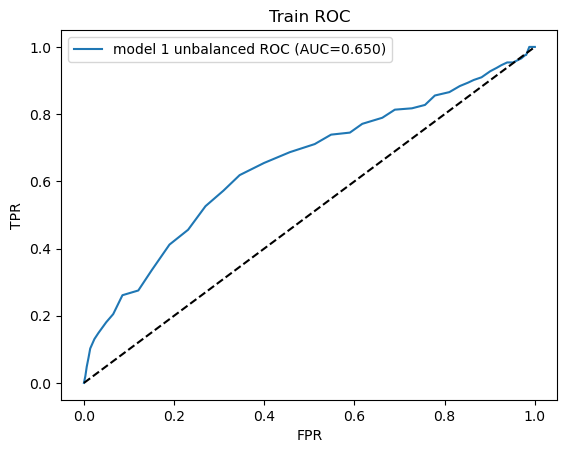

AUC (model 1 unbalanced, Train): 0.650


In [131]:
cm_df_1_un, auc_f1_1_un = evaluate_model_plot(attrition_train, model1_unbalanced, 'Attrition_lab',
    model_1_features  , score=0.5, model_name='model 1 unbalanced', dataset_name='Train')


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.598
Recall (train):    0.687


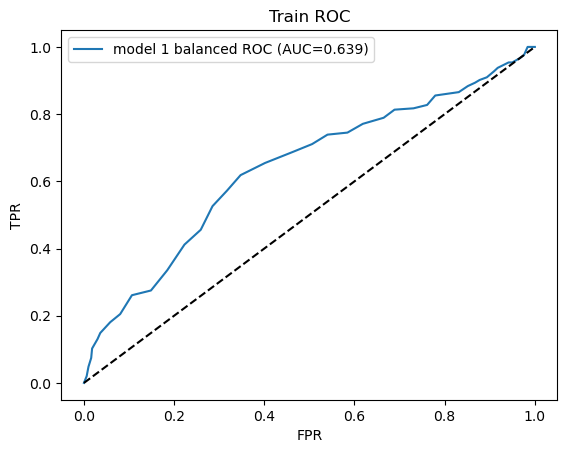

AUC (model 1 balanced, Train): 0.639


In [132]:
cm_df_1_bal, auc_f1_1_bal = evaluate_model_plot(attrition_train_bal, model1, 'Attrition_lab',
    model_1_features  , score=0.5, model_name='model 1 balanced', dataset_name='Train')

---


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


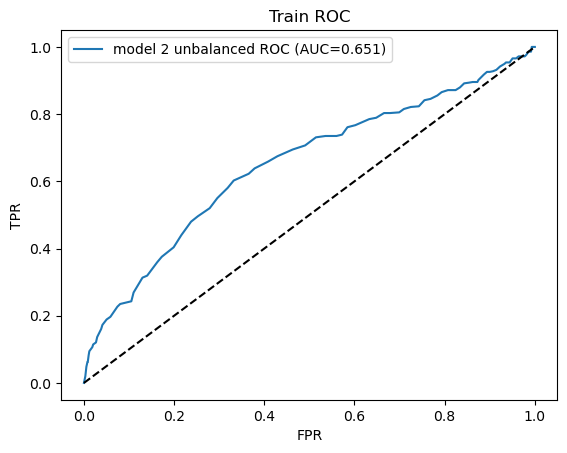

AUC (model 2 unbalanced, Train): 0.651


In [133]:
cm_df_2_un, auc_f1_2_un = evaluate_model_plot(attrition_train, model2_unbalanced, 'Attrition_lab',
    model_2_features  , score=0.5, model_name='model 2 unbalanced', dataset_name='Train')


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.610
Recall (train):    0.675


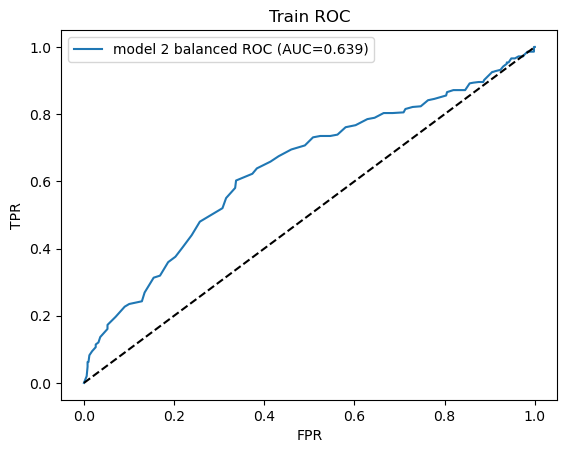

AUC (model 2 balanced, Train): 0.639


In [134]:
cm_df_2_bal, auc_f1_2_bal = evaluate_model_plot(attrition_train_bal, model2, 'Attrition_lab',
    model_2_features  , score=0.5, model_name='model 2 balanced', dataset_name='Train')

---


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


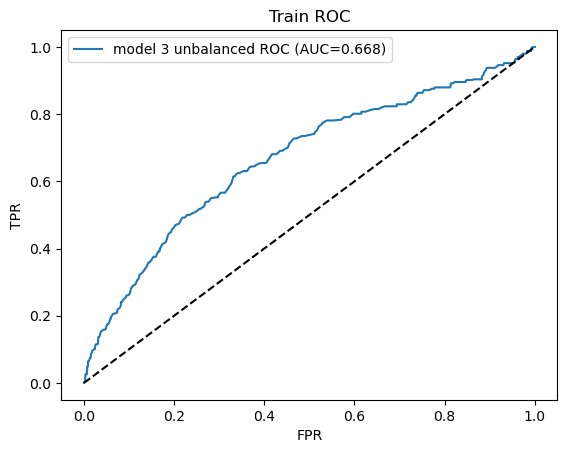

AUC (model 3 unbalanced, Train): 0.668


In [135]:
cm_df_3_un, auc_f1_3_un = evaluate_model_plot(attrition_train, model3_unbalanced, 'Attrition_lab',
    model_3_features  , score=0.5, model_name='model 3 unbalanced', dataset_name='Train')


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.621
Recall (train):    0.631


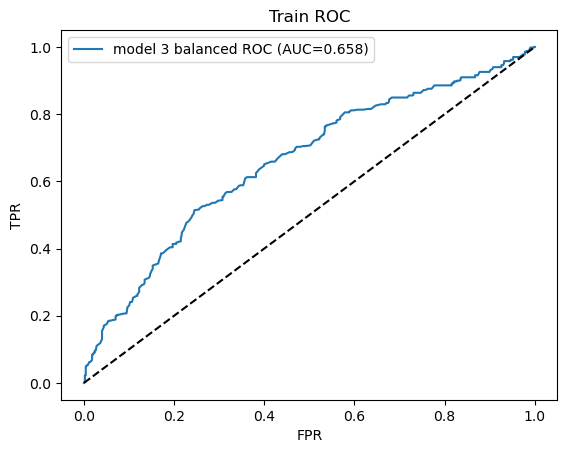

AUC (model 3 balanced, Train): 0.658


In [136]:
cm_df_3_bal, auc_f1_3_bal = evaluate_model_plot(attrition_train_bal, model3, 'Attrition_lab',
    model_3_features  , score=0.5, model_name='model 3 balanced', dataset_name='Train')

---


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.000
Recall (train):    0.000


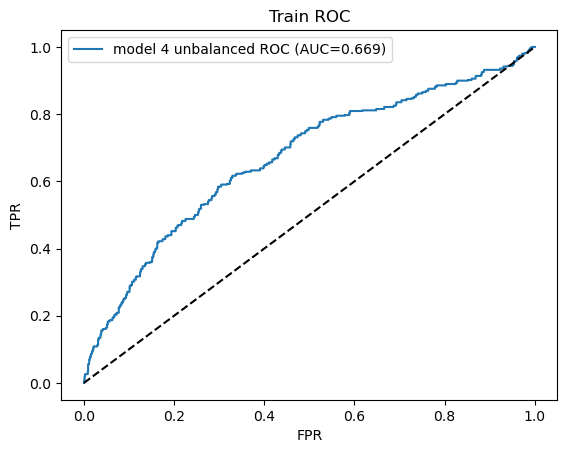

AUC (model 4 unbalanced, Train): 0.669


In [137]:
cm_df_4_un, auc_f1_4_un = evaluate_model_plot(attrition_train, model4_unbalanced, 'Attrition_lab',
    model_4_features  , score=0.5, model_name='model 4 unbalanced', dataset_name='Train')


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.618
Recall (train):    0.635


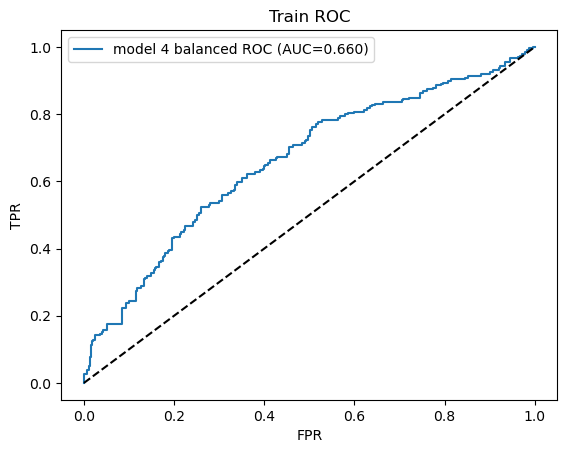

AUC (model 4 balanced, Train): 0.660


In [138]:
cm_df_4_bal, auc_f1_4_bal = evaluate_model_plot(attrition_train_bal, model4, 'Attrition_lab',
    model_4_features  , score=0.5, model_name='model 4 balanced', dataset_name='Train')

---


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.724
Recall (train):    0.153


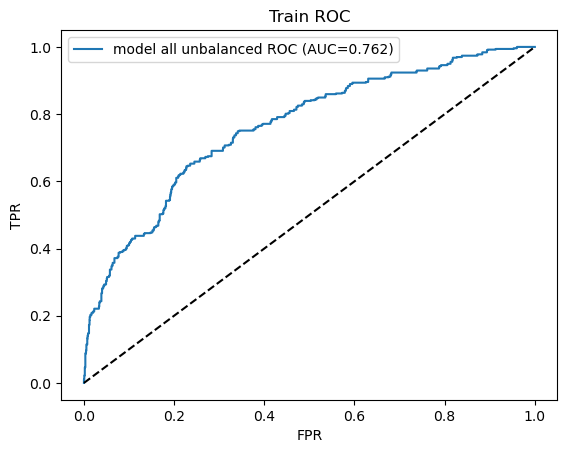

AUC (model all unbalanced, Train): 0.762


In [139]:
cm_df_all_un, auc_f1_all_un = evaluate_model_plot(attrition_train, model_all_unbalanced, 'Attrition_lab',
    predictors  , score=0.5, model_name='model all unbalanced', dataset_name='Train')


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.699
Recall (train):    0.705


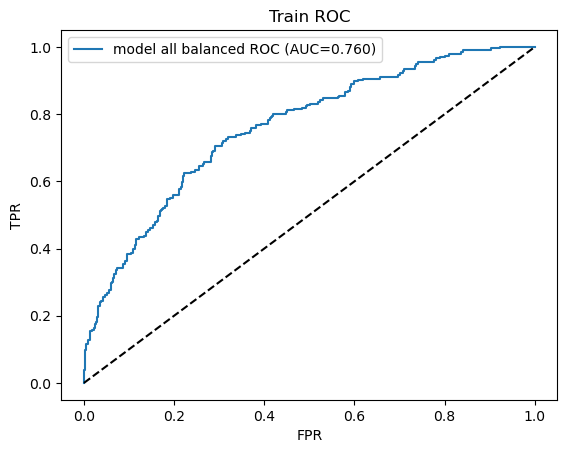

AUC (model all balanced, Train): 0.760


In [140]:
cm_df_all_bal, auc_f1_all_bal = evaluate_model_plot(attrition_train_bal, model_all, 'Attrition_lab',
    predictors  , score=0.5, model_name='model all balanced', dataset_name='Train')

---

# Question 3
#### Predictive Performance - Using the logistic regression models that you have developed, perform a prediction analysis for employee attrition. 
- For each of the four models, calculate the predicted probabilities of employee attrition for the test dataset.
- Calculate predicted probabilities for each model using the test dataset
- Create ROC curve objects for each model
- Create ROC curves for each model to evaluate their discriminatory power in predicting attrition.
- Plot ROC curves for all four models on one plot
- Compare the ROC curves and AUC. Discuss which model appears to be the most effective in distinguishing between employees with and without attrition.

---

#### Test set predictions and evaulations

In [141]:
test_probs1_un = model1_unbalanced.predict(sm.add_constant(attrition_test[model_1_features]))
test_probs1_bal = model1.predict(sm.add_constant(attrition_test[model_1_features]))
auc_test1_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs1_un)
auc_test1_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs1_bal)
test_auc_df_1 = pd.DataFrame({
    "Model": ["model 1 unbalanced", "model 1 balanced"],
    "AUC": [auc_test1_un, auc_test1_bal]
})
test_auc_df_1

,Model,AUC
0,model 1 unbalanced,0.595912
1,model 1 balanced,0.595912


In [142]:
test_probs2_un = model2_unbalanced.predict(sm.add_constant(attrition_test[model_2_features]))
test_probs2_bal = model2.predict(sm.add_constant(attrition_test[model_2_features]))
auc_test2_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs2_un)
auc_test2_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs2_bal)
test_auc_df_2 = pd.DataFrame({
    "Model": ["model 2 unbalanced", "model 2 balanced"],
    "AUC": [auc_test2_un, auc_test2_bal]
})
test_auc_df_2

,Model,AUC
0,model 2 unbalanced,0.596411
1,model 2 balanced,0.596411


In [143]:
test_probs3_un = model3_unbalanced.predict(sm.add_constant(attrition_test[model_3_features]))
test_probs3_bal = model3.predict(sm.add_constant(attrition_test[model_3_features]))
auc_test3_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs3_un)
auc_test3_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs3_bal)
test_auc_df_3 = pd.DataFrame({
    "Model": ["model 3 unbalanced", "model 3 balanced"],
    "AUC": [auc_test3_un, auc_test3_bal]
})
test_auc_df_3

,Model,AUC
0,model 3 unbalanced,0.627609
1,model 3 balanced,0.628205


In [144]:
test_probs4_un = model4_unbalanced.predict(sm.add_constant(attrition_test[model_4_features]))
test_probs4_bal = model4.predict(sm.add_constant(attrition_test[model_4_features]))
auc_test4_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs4_un)
auc_test4_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs4_bal)
test_auc_df_4 = pd.DataFrame({
    "Model": ["model 4 unbalanced", "model 4 balanced"],
    "AUC": [auc_test4_un, auc_test4_bal]
})
test_auc_df_4

,Model,AUC
0,model 4 unbalanced,0.631455
1,model 4 balanced,0.633058


In [145]:
test_probs_all_un = model_all_unbalanced.predict(sm.add_constant(attrition_test[predictors]))
test_probs_all_bal = model_all.predict(sm.add_constant(attrition_test[predictors]))
auc_test_all_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs_all_un)
auc_test_all_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs_all_bal)
test_auc_all = pd.DataFrame({
    "Model": ["model all unbalanced", "model all balanced"],
    "AUC": [auc_test_all_un, auc_test_all_bal]
})
test_auc_all

,Model,AUC
0,model all unbalanced,0.740507
1,model all balanced,0.739327


#### interesting to note that the unbalanced dataset did better than the balanced dataset

---

#### Test to see if there is a better set of features to use (will be using StepWise Feature Selection)

In [146]:
# -------------------------------------------------------------------
# Stepwise-like selection with mlxtend (wrapper around sklearn)
# We use LogisticRegression (sklearn) + AUC scoring. Then refit in statsmodels.
# -------------------------------------------------------------------

# this takes a long time, so let's do this on a random sample of 1,000 obs


stepwise_model = SFS(
    LogisticRegression(solver="lbfgs", max_iter=1000),
    k_features = 7, # we can let the model choose or set a range as before
    forward = True,
    floating = True,
    scoring = "roc_auc", # maximum AUC
    cv = 5,
    n_jobs = -1 # use all available cores to build models in parallel
)

stepwise_model = stepwise_model.fit(
    attrition_train_bal[predictors],
    attrition_train_bal["Attrition_lab"]
    )

# get selected predictors
selected_idx = list(stepwise_model.k_feature_idx_)

selected_cols = [predictors[i] for i in selected_idx]

print("Selected features by SFS:", selected_cols)

Selected features by SFS: ['NumCompaniesWorked', 'YearsAtCompany', 'YearsWithCurrManager', 'JobSatisfaction', 'BusinessTravel_Travel_Frequently', 'MaritalStatus_Single', 'Age_simple_lab']


In [147]:
selected_cols

['NumCompaniesWorked',
 'YearsAtCompany',
 'YearsWithCurrManager',
 'JobSatisfaction',
 'BusinessTravel_Travel_Frequently',
 'MaritalStatus_Single',
 'Age_simple_lab']

#### found the best features to use via stepwise selection

---

#### create a model and test to see the differences between the unbalanced and balanced dataset

In [148]:
print('Unbalanced')
modelSFS_unbalanced = log_reg_summary(attrition_train , 'Attrition_lab' , selected_cols)
print('=================================================================================')
print('=================================================================================')
print('=================================================================================')
print('Balanced')
modelSFS = log_reg_summary(attrition_train_bal , 'Attrition_lab' , selected_cols)


Unbalanced
Optimization terminated successfully.
         Current function value: 0.387765
         Iterations 7

=== f1 summary (7 features)===
                           Logit Regression Results                           
Dep. Variable:          Attrition_lab   No. Observations:                 3087
Model:                          Logit   Df Residuals:                     3079
Method:                           MLE   Df Model:                            7
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.1224
Time:                        22:15:18   Log-Likelihood:                -1197.0
converged:                       True   LL-Null:                       -1364.0
Covariance Type:            nonrobust   LLR p-value:                 3.350e-68
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                

---

#### Test to see the VIF on the balanced and unbalanced models

In [149]:
print('Unbalanced')
print_vif(modelSFS_unbalanced)

Unbalanced


,variable,VIF
0,const,14.549021
1,NumCompaniesWorked,1.135224
2,YearsAtCompany,2.573237
3,YearsWithCurrManager,2.444824
4,JobSatisfaction,1.006184
5,BusinessTravel_Travel_Frequently,1.002785
6,MaritalStatus_Single,1.011451
7,Age_simple_lab,1.191026


In [150]:
print('Balanced')
print_vif(modelSFS)

Balanced


,variable,VIF
0,const,14.261063
1,NumCompaniesWorked,1.107180
2,YearsAtCompany,2.715115
3,YearsWithCurrManager,2.557795
4,JobSatisfaction,1.018644
5,BusinessTravel_Travel_Frequently,1.024485
6,MaritalStatus_Single,1.034287
7,Age_simple_lab,1.213193


---

#### test to see the model precision and recall

In [151]:
print('Unbalanced')
evaulate_model(attrition_train , modelSFS_unbalanced , 'Attrition_lab',
               selected_cols , 0.5)

Unbalanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.652
Recall (train):    0.086


,Pred 0,Pred 1
Actual 0,2566,23
Actual 1,455,43


In [152]:
print('Balanced')
evaulate_model(attrition_train_bal , modelSFS , 'Attrition_lab',
               selected_cols , 0.5)

Balanced

In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.697
Recall (train):    0.693


,Pred 0,Pred 1
Actual 0,348,150
Actual 1,153,345



In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.652
Recall (train):    0.086


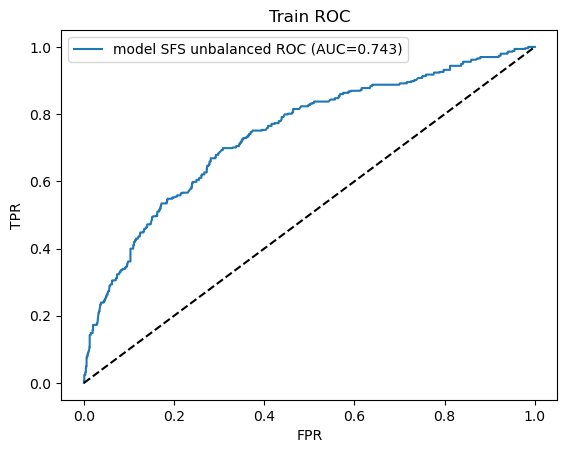

AUC (model SFS unbalanced, Train): 0.743


In [153]:
cm_df_SFS_un, auc_f1_SFS_un = evaluate_model_plot(attrition_train, modelSFS_unbalanced, 'Attrition_lab',
    selected_cols  , score=0.5, model_name='model SFS unbalanced', dataset_name='Train')


In-sample confusion matrix (threshold = 0.5):

Precision (train): 0.697
Recall (train):    0.693


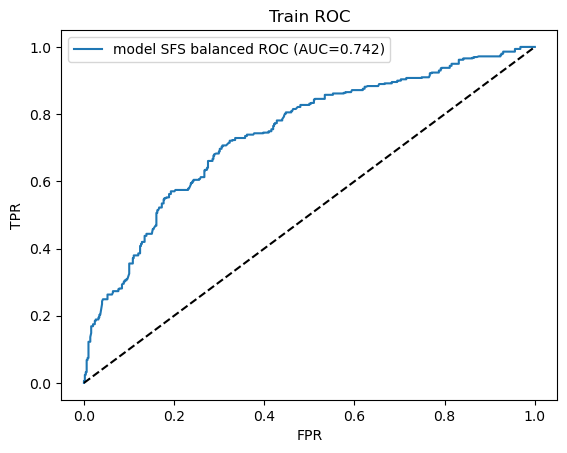

AUC (model SFS balanced, Train): 0.742


In [154]:
cm_df_SFS_bal, auc_f1_SFS_bal = evaluate_model_plot(attrition_train_bal, modelSFS, 'Attrition_lab',
    selected_cols  , score=0.5, model_name='model SFS balanced', dataset_name='Train')

In [155]:
test_probs_SFS_un = modelSFS_unbalanced.predict(sm.add_constant(attrition_test[selected_cols]))
test_probs_SFS_bal = modelSFS.predict(sm.add_constant(attrition_test[selected_cols]))
auc_test_SFS_un = roc_auc_score(attrition_test["Attrition_lab"], test_probs_SFS_un)
auc_test_SFS_bal = roc_auc_score(attrition_test["Attrition_lab"], test_probs_SFS_bal)
test_auc_SFS = pd.DataFrame({
    "Model": ["model SFS unbalanced", "model SFS balanced"],
    "AUC": [auc_test_SFS_un, auc_test_SFS_bal]
})
test_auc_SFS

,Model,AUC
0,model SFS unbalanced,0.706391
1,model SFS balanced,0.710663


---

# lets try to create a more comprehensive model. Now that we have used SFS to find the best features to use (selected_cols)

#### Explore scaling the data and using pipelines to impute instead of using the medium, will try to feature engineer within the CV
- recap: the balanced dataset is attrition_train_bal , attrition_test
- model_1_features , model_2_features, model_3_features, model_4_features, predictors , and selected_cols


In [156]:
## data preprocessing:

df2 = pd.read_excel('Employee_Data_Project.xlsx')

a_train , a_test = train_test_split(
    df2, 
    test_size=0.3, 
    random_state= 42, 
    stratify=df2['Attrition']
)

a_train['Attrition_lab'] = (a_train['Attrition'] == "Yes").astype(int)
a_test['Attrition_lab'] = (a_test['Attrition'] == "Yes").astype(int)
categorical_columns = ['BusinessTravel', 'Gender', 'MaritalStatus']
a_train = pd.get_dummies(a_train, columns=categorical_columns, drop_first=True, dtype=int)
a_test = pd.get_dummies(a_test, columns = categorical_columns, drop_first= True, dtype = int )
a_train['Gender:Income'] = a_train['Income'] * a_train['Gender_Male']
a_test['Gender:Income'] = a_test['Income'] * a_test['Gender_Male']



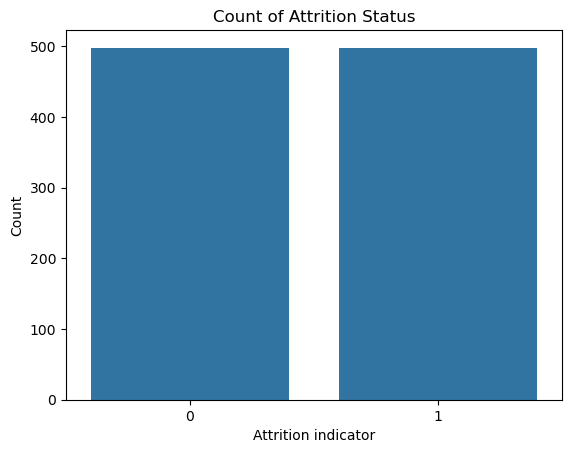

In [ ]:
#### --------------------- ####

# Class imbalance: downsample the negative class; keep all positives
# + equal number of negatives
np.random.seed(42)
pos_idx1 = a_train.index[a_train["Attrition_lab"] == 1]
neg_idx1 = a_train.index[a_train["Attrition_lab"] == 0]

keep_neg1= np.random.choice(neg_idx1, size=len(pos_idx1), replace=False)
keep_idx1 = np.concatenate([pos_idx1, keep_neg1])

a_train_bal = a_train.loc[keep_idx1].copy()

# Quick look after balancing
sns.countplot(data = a_train_bal, x="Attrition_lab")
plt.xlabel("Attrition indicator")
plt.ylabel("Count")
plt.title("Count of Attrition Status")
plt.show()

#### --------------------- ####

---

#### there will be nulls in this data set
- in pipeline first thing to do is to use knn_imputer to impute the missing values 
- then the features will be scaled using standard scaler 
- then the model will be fit using logistic regression

In [158]:
a_train['Age_simple'] = pd.cut(a_train['Age'], bins = [0, 35, 100] , labels=['35 and Younger' , 'Over 35'] )
a_train['Age_simple_lab'] = (a_train['Age_simple'] == "35 and Younger").astype(int)
a_train_bal['Age_simple'] = pd.cut(a_train_bal['Age'], bins = [0, 35, 100] , labels=['35 and Younger' , 'Over 35'] )
a_train_bal['Age_simple_lab'] = (a_train_bal['Age_simple'] == "35 and Younger").astype(int)
a_test['Age_simple'] = pd.cut(a_test['Age'], bins = [0, 35, 100] , labels=['35 and Younger' , 'Over 35'] )
a_test['Age_simple_lab'] = (a_test['Age_simple'] == "35 and Younger").astype(int)

In [159]:
model_1_features = ['Age']
model_1_features_update = ['Age_simple_lab']
model_2_features = ['Age', 'Gender_Male']
model_2_features_update = ['Age_simple_lab', 'Gender_Male']
model_3_features = ['Age' , 'Gender_Male' , 'JobSatisfaction']
model_3_features_update = ['Age_simple_lab' , 'Gender_Male' , 'JobSatisfaction']
model_4_features = ['Age' , 'Gender_Male' , 'JobSatisfaction' , 'Income' , 'Gender:Income' ]
model_4_features_update = ['Age_simple_lab' , 'Gender_Male' , 'JobSatisfaction' , 'Income' , 'Gender:Income' ]
predictors = attrition_train_bal.columns.tolist()
### need to remove Attrition, EmployeeID , StandardHours , Attrition_lab
predictors.remove('Attrition_lab')
predictors.remove('Age')
predictors.remove('Age_simple')
predictors.remove('Attrition')
predictors.remove('EmployeeID')
predictors.remove('StandardHours')
predictors


['DistanceFromHome',
 'Education',
 'JobLevel',
 'Income',
 'NumCompaniesWorked',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsWithCurrManager',
 'EnvironmentSatisfaction',
 'JobSatisfaction',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Gender_Male',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Age_simple_lab',
 'Gender:Income']

In [160]:
def train_evaluate_knn_logistic_regression_with_cv(trainset, testset, predictors, cv_folds=5):
    # Create copies
    train_copy = trainset.copy()
    test_copy = testset.copy()
    # KNN Imputation
    imputer_knn = KNNImputer(n_neighbors=5)
    train_copy[predictors] = imputer_knn.fit_transform(train_copy[predictors])
    test_copy[predictors] = imputer_knn.transform(test_copy[predictors])  
    # Scaling using standandrd scaler
    scaler = StandardScaler()
    train_copy[predictors] = scaler.fit_transform(train_copy[predictors])
    test_copy[predictors] = scaler.transform(test_copy[predictors])  
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    # Initialize model
    log_reg = LogisticRegression(max_iter=5000, random_state=42)
    # Perform cross-validation
    cv_scores = cross_val_score(
        log_reg, 
        train_copy[predictors], 
        train_copy['Attrition_lab'],
        cv=cv,
        scoring='roc_auc'
    )
    log_reg.fit(train_copy[predictors], train_copy['Attrition_lab'])
    train_probs = log_reg.predict_proba(train_copy[predictors])[:,1]
    train_auc = roc_auc_score(train_copy['Attrition_lab'], train_probs)
    test_probs = log_reg.predict_proba(test_copy[predictors])[:,1]
    test_preds = (test_probs >= 0.5).astype(int)
    test_auc = roc_auc_score(test_copy['Attrition_lab'], test_probs)
    test_precision = precision_score(test_copy['Attrition_lab'], test_preds , zero_division= 0)
    test_recall = recall_score(test_copy['Attrition_lab'], test_preds)
    return {
        'model': log_reg,
        'cv_scores': cv_scores,
        'cv_auc_mean': cv_scores.mean(),
        'train_auc': train_auc,
        'test_auc': test_auc,
        'test_precision': test_precision,
        'test_recall': test_recall
    }

---

need to create a dictionary to run all of these in a for loop to create a table with all of the results.

In [161]:
runs = {
    'model 1 full dataset' : [a_train, a_test, model_1_features],
    'model 1 full dataset, age binary' : [a_train, a_test, model_1_features_update],
    'model 1 downsampled' : [a_train_bal, a_test, model_1_features],
    'model 1 downsampled, age binary' : [a_train_bal, a_test, model_1_features_update],
    'model 2 full dataset' : [a_train, a_test, model_2_features],
    'model 2 full dataset, age binary' : [a_train, a_test, model_2_features_update],
    'model 2 downsampled' : [a_train_bal, a_test, model_2_features],
    'model 2 downsampled, age binary' : [a_train_bal, a_test, model_2_features_update],
    'model 3 full dataset' : [a_train, a_test, model_3_features],
    'model 3 full dataset, age binary' : [a_train, a_test, model_3_features_update],
    'model 3 downsampled' : [a_train_bal, a_test, model_3_features],
    'model 3 downsampled, age binary' : [a_train_bal, a_test, model_3_features_update],
    'model 4 full dataset' : [a_train, a_test, model_4_features],
    'model 4 full dataset, age binary' : [a_train, a_test, model_4_features_update],
    'model 4 downsampled' : [a_train_bal, a_test, model_4_features],
    'model 4 downsampled, age binary' : [a_train_bal, a_test, model_4_features_update],
    'model 5 all predictors' : [a_train, a_test, predictors],
    'model 5 all predictors downsampled' : [a_train_bal, a_test, predictors],
    'model 6 SFS' : [a_train, a_test, selected_cols],
    'model 6 SFS, downsampled' : [a_train_bal, a_test, selected_cols]
}

In [162]:
runs_stats = []
for i , j in runs.items():
    trainset, testset, predictors = j 
    results = train_evaluate_knn_logistic_regression_with_cv(
        trainset = trainset, 
        testset = testset,
        predictors = predictors, 
        cv_folds = 5)
    runs_stats.append({
        'Model' : i, 
        'CV_AUC_Mean' : results['cv_auc_mean'],
        'Train_AUC' : results['train_auc'],
        'Test_AUC' : results['test_auc'],
        'Test_Precision' : results['test_precision'],
        'Test_Recall' : results['test_recall']
    })

# Create DataFrame
results_df = pd.DataFrame(runs_stats)
results_df

,Model,CV_AUC_Mean,Train_AUC,Test_AUC,Test_Precision,Test_Recall
0,model 1 full dataset,0.650293,0.650388,0.595912,0.000000,0.000000
1,"model 1 full dataset, age binary",0.615025,0.615100,0.587457,0.000000,0.000000
2,model 1 downsampled,0.638913,0.638677,0.595912,0.208145,0.647887
3,"model 1 downsampled, age binary",0.612364,0.612450,0.587457,0.208145,0.647887
4,model 2 full dataset,0.648648,0.650623,0.596411,0.000000,0.000000
5,"model 2 full dataset, age binary",0.608697,0.621605,0.588688,0.000000,0.000000
6,model 2 downsampled,0.638062,0.639008,0.596411,0.214626,0.633803
7,"model 2 downsampled, age binary",0.615765,0.616797,0.588688,0.208145,0.647887
8,model 3 full dataset,0.664497,0.667574,0.626890,0.000000,0.000000
9,"model 3 full dataset, age binary",0.651909,0.652096,0.631405,0.000000,0.000000


---

Need to clean up the table a little before 

In [163]:
results_data = {
    'Model' :[ 'Model 1 (Age)' , 'Model 2 (Age + Gender)' , 'Model 3 (Age + Gender + Job Satisfaction)' , 'Model 4 (Interaction)', 'Model 5 (All Features)' , 
    'Model 6 (SFS features)'],
    'Mean CV AUC' : [0.612364, 0.615765, 0.651909 , 0.648722 , 0.740013 , 0.735932], 
    'Train AUC': [0.612450 , 0.616797 , 0.652407 , 0.652570 , 0.759455 , 0.742986 ],
    'Test AUC' : [0.587457 , 0.588688 , 0.631290 , 0.636489 , 0.738485 , 0.710274 ],
    'Test Precision' : [0.208145 , 0.208145 , 0.219895 , 0.214984, 0.308696 , 0.281319], 
    'Test Recall' : [0.647887, 0.647887, 0.591549 , 0.619718 , 0.666667 , 0.600939]
    }

df_comparison_table = pd.DataFrame(results_data)

pivot_df = df_comparison_table.melt(
    id_vars=['Model'], 
    value_vars=['Mean CV AUC', 'Train AUC' , 'Test AUC', 'Test Precision', 'Test Recall'],
    var_name='Metric', 
    value_name='Value'
)



In [ ]:
#### *********************** ####

alt.Chart(pivot_df).mark_bar().encode(
    x=alt.X('Metric:N' , title = 'Performance Metric'),
    y = alt.Y('Value:Q', title = 'Score'), 
    color = alt.Color('Model:N' , title = 'Model'),
    xOffset= 'Model:N'
).properties(
    width = 800,
    height = 600
)

#### *********************** ####


alt.Chart(...)

---

In [165]:
def get_roc(trainset, testset, features):
    df_train = trainset.copy()
    df_test = testset.copy()
    # Impute
    imputer = KNNImputer(n_neighbors=5)
    df_train[features] = imputer.fit_transform(df_train[features])
    df_test[features] = imputer.transform(df_test[features]) 
    # Scale
    scaler = StandardScaler()
    df_train[features] = scaler.fit_transform(df_train[features])
    df_test[features] = scaler.transform(df_test[features]) 
    # Train
    model = LogisticRegression(max_iter=1000)
    model.fit(df_train[features], df_train['Attrition_lab'])
    # Predict on TEST set
    y_pred = model.predict_proba(df_test[features])[:, 1]  
    # ROC
    fpr, tpr, _ = roc_curve(df_test['Attrition_lab'], y_pred)
    auc = roc_auc_score(df_test['Attrition_lab'], y_pred) 
    return fpr, tpr, auc

---

#### Create Plots

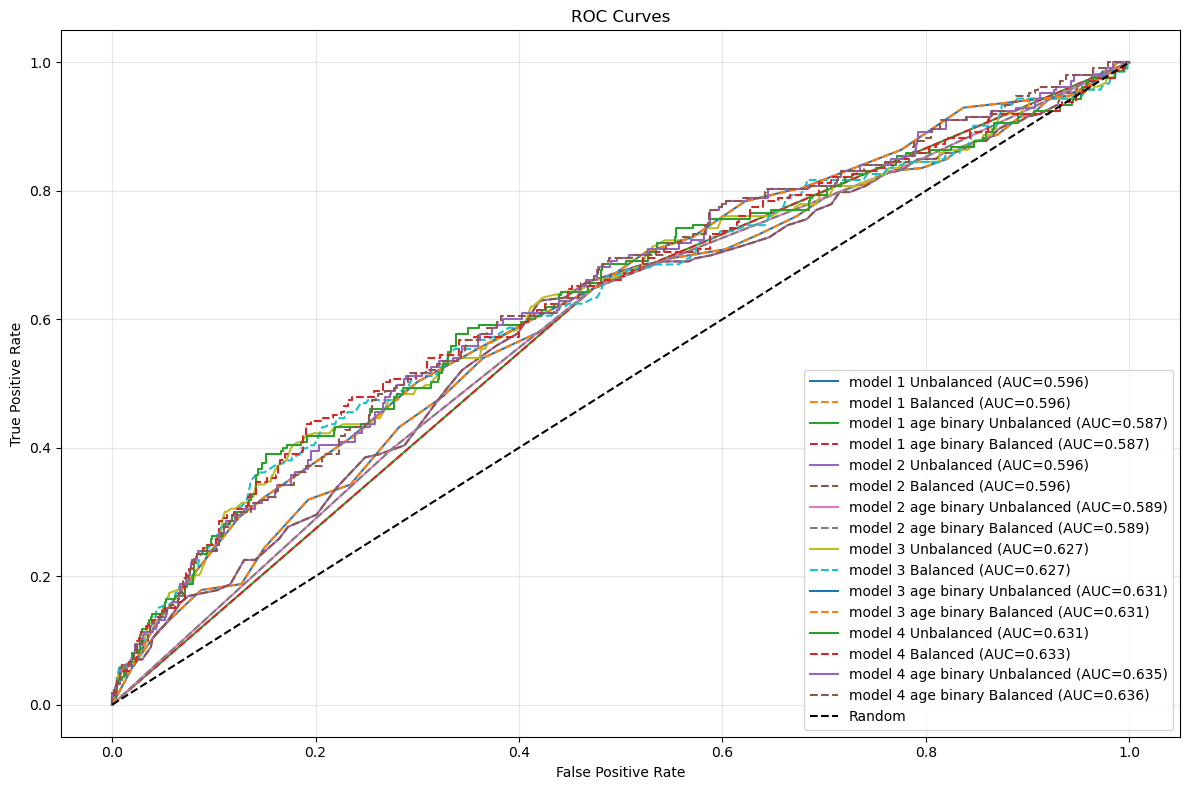

In [ ]:
#### -------------------------- ####

models = {
    'model 1' : model_1_features, 
    'model 1 age binary' : model_1_features_update, 
    'model 2' : model_2_features,
    'model 2 age binary' : model_2_features_update, 
    'model 3' : model_3_features, 
    'model 3 age binary' : model_3_features_update, 
    'model 4' : model_4_features, 
    'model 4 age binary' : model_4_features_update, 
}
fig, ax = plt.subplots(figsize=(12, 8))

for name, features in models.items():
    # Unbalanced
    fpr_u, tpr_u, auc_u = get_roc(a_train, a_test, features)
    ax.plot(fpr_u, tpr_u, linestyle='-', label=f'{name} Unbalanced (AUC={auc_u:.3f})')
    # Balanced
    fpr_b, tpr_b, auc_b = get_roc(a_train_bal, a_test, features)
    ax.plot(fpr_b, tpr_b, linestyle='--', label=f'{name} Balanced (AUC={auc_b:.3f})')
# Random classifier
ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### -------------------------- ####


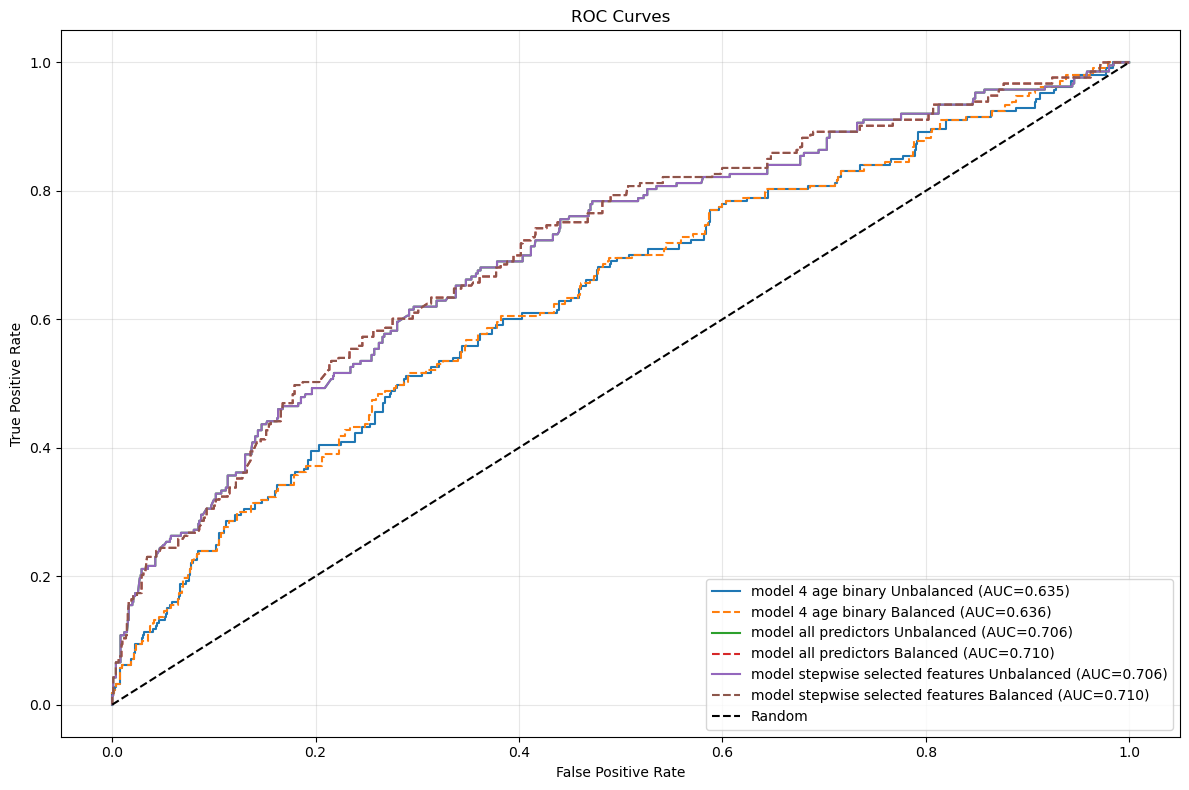

In [ ]:
#### -------------------------- ####
models = {
    'model 4 age binary' : model_4_features_update,
    'model all predictors' : predictors,
    'model stepwise selected features' : selected_cols
}
fig, ax = plt.subplots(figsize=(12, 8))

for name, features in models.items():
    # Unbalanced
    fpr_u, tpr_u, auc_u = get_roc(a_train, a_test, features)
    ax.plot(fpr_u, tpr_u, linestyle='-', label=f'{name} Unbalanced (AUC={auc_u:.3f})')
    # Balanced
    fpr_b, tpr_b, auc_b = get_roc(a_train_bal, a_test, features)
    ax.plot(fpr_b, tpr_b, linestyle='--', label=f'{name} Balanced (AUC={auc_b:.3f})')
# Random classifier
ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
#### -------------------------- ####


---